In [2]:
import multiprocessing as mp
mp.set_start_method("spawn", force=True)

### automatically refresh the buffer
%load_ext autoreload
%autoreload 2

### solve the auto-complete issue

%config Completer.use_jedi = False
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter(action='ignore', category=FutureWarning)

### lvl 2 setups (systerm)
import os
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib as mpl
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from scipy.stats import linregress
from matplotlib.colors import ListedColormap,LinearSegmentedColormap,BoundaryNorm
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
import geopandas as gpd
from shapely.geometry import Point
from datetime import datetime
import shap
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.nonparametric.smoothers_lowess import lowess

In [3]:
df_ena_abs = pd.read_csv('/data/ggong/ARM_monthly/ENA/csv_file/df_abs.csv')
df_sgp_abs = pd.read_csv('/data/ggong/ARM_monthly/SGP/csv_file/df_abs.csv')

### ARM Seasonal occurrence fractions, Fig. S3


ENA counts:
label   bottom  middle  top
season                     
DJF        531     327   64
MAM        385     225   40
JJA        786     280   81
SON        504     384   51

ENA percentage:
label   bottom  middle  top
season                     
DJF       57.6    35.5  6.9
MAM       59.2    34.6  6.2
JJA       68.5    24.4  7.1
SON       53.7    40.9  5.4

SGP counts:
label   bottom  middle  top
season                     
DJF         37      91    0
MAM        325     141    4
JJA         73      24    1
SON        172      49    3

SGP percentage:
label   bottom  middle  top
season                     
DJF       28.9    71.1  0.0
MAM       69.1    30.0  0.9
JJA       74.5    24.5  1.0
SON       76.8    21.9  1.3


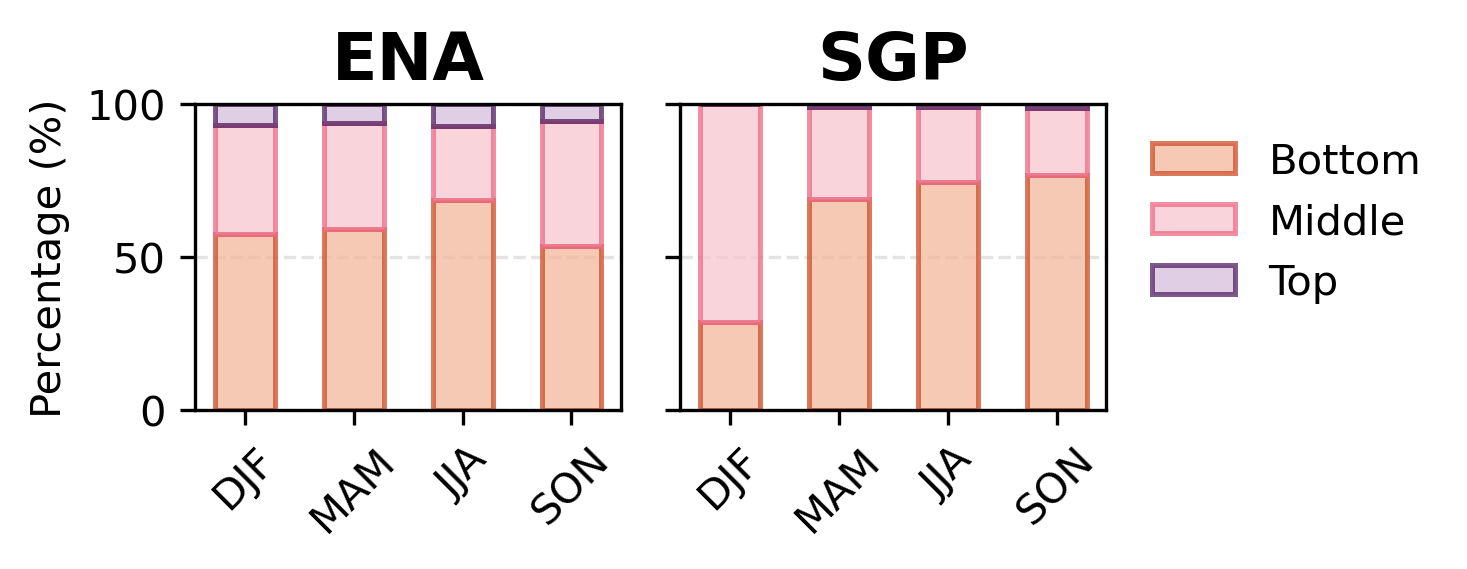

In [4]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt

dfs = {"ENA": df_ena_abs, "SGP": df_sgp_abs}
smap = {12:"DJF",1:"DJF",2:"DJF",3:"MAM",4:"MAM",5:"MAM",6:"JJA",7:"JJA",8:"JJA",9:"SON",10:"SON",11:"SON"}
seasons, labels = ["DJF","MAM","JJA","SON"], ["bottom","middle","top"]
colors, edges = ["#f3b79c","#f7c6d0","#d6c0db"], ["#cf4e28","#ee6a85","#532162"]

fig, axes = plt.subplots(1, 2, figsize=(5, 2), dpi=300, sharey=True)

for ax, (site, d) in zip(axes, dfs.items()):
    d = d.copy()
    d["season"] = d["month"].map(smap)
    d["label"] = d["label"].str.lower()

    cnt = pd.crosstab(d["season"], d["label"]).reindex(index=seasons, columns=labels, fill_value=0)
    pct = cnt.div(cnt.sum(1), axis=0).mul(100)

    print(f"\n{site} counts:\n{cnt}")
    print(f"\n{site} percentage:\n{pct.round(1)}")

    bot = np.zeros(len(pct))
    for lab, fc, ec in zip(labels, colors, edges):
        ax.bar(pct.index, pct[lab], bottom=bot, color=fc, edgecolor=ec,
               width=0.55, lw=1.2, alpha=0.75, label=lab.capitalize())
        bot += pct[lab].values

    ax.set_title(site, fontsize=16, weight="bold")
    ax.set_ylim(0, 100)
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", ls="--", alpha=0.35)
    ax.set_axisbelow(True)

axes[0].set_ylabel("Percentage (%)")
axes[1].legend(frameon=False, loc="upper left", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.savefig("figsave/seasonal_abs_percentage.pdf", dpi=300, bbox_inches="tight")
plt.show()

## Fig.2a

Counts:
 label  bottom  middle  top
ENA      2206    1216  236
SGP       607     305    8

Percentages:
 label  bottom  middle  top
ENA      60.3    33.2  6.5
SGP      66.0    33.2  0.9


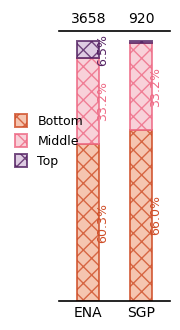

In [5]:
dfs = {"ENA": df_ena_abs, "SGP": df_sgp_abs}
cats = ["bottom", "middle", "top"]
labels = {"bottom":"Bottom", "middle":"Middle", "top":"Top"}
colors = {"bottom":"#f3b79c", "middle":"#f7c6d0", "top":"#d6c0db"}
edges  = {"bottom":"#cf4e28", "middle":"#ee6a85", "top":"#532162"}

cnt = pd.DataFrame({s: d["label"].astype(str).str.lower().value_counts().reindex(cats, fill_value=0) for s, d in dfs.items()}).T
pct = cnt.div(cnt.sum(1), axis=0) * 100

print("Counts:\n", cnt)
print("\nPercentages:\n", pct.round(1))

fig, ax = plt.subplots(figsize=(2.2, 3.4), dpi=100)
x, bot = np.arange(len(dfs)), np.zeros(len(dfs))

for c in cats:
    vals = pct[c].values
    ax.bar(x, vals, bottom=bot, width=0.42, color=colors[c], edgecolor=edges[c], lw=1.4, alpha=0.8, hatch="xx", label=labels[c], zorder=2)
    for xi, v, b in zip(x, vals, bot):
        if v > 3:
            ax.text(xi + 0.27, b + v/2, f"{v:.1f}%", ha="center", va="center", rotation=90, fontsize=9, color=edges[c], zorder=10, clip_on=False)
    bot += vals

for xi, site in zip(x, dfs):
    ax.text(xi, 106, f"{cnt.loc[site].sum():.0f}", ha="center", va="bottom", fontsize=10, zorder=10, clip_on=False)

ax.set(xticks=x, xticklabels=list(dfs), xlim=(-0.55, len(dfs)-0.45), ylim=(0,112), yticks=[])
ax.tick_params(axis="x", length=0)
for s in ["left", "right", "top"]: ax.spines[s].set_visible(False)
ax.spines["bottom"].set_linewidth(1.2)
ax.axhline(104, color="k", lw=1.2, clip_on=False, zorder=1)
ax.legend(frameon=False, fontsize=9, loc="center left", bbox_to_anchor=(-0.5, 0.55), handlelength=1, handleheight=1.2)
plt.tight_layout()
plt.show()

## Cloud droplet radius sensitivity, Fig. 3

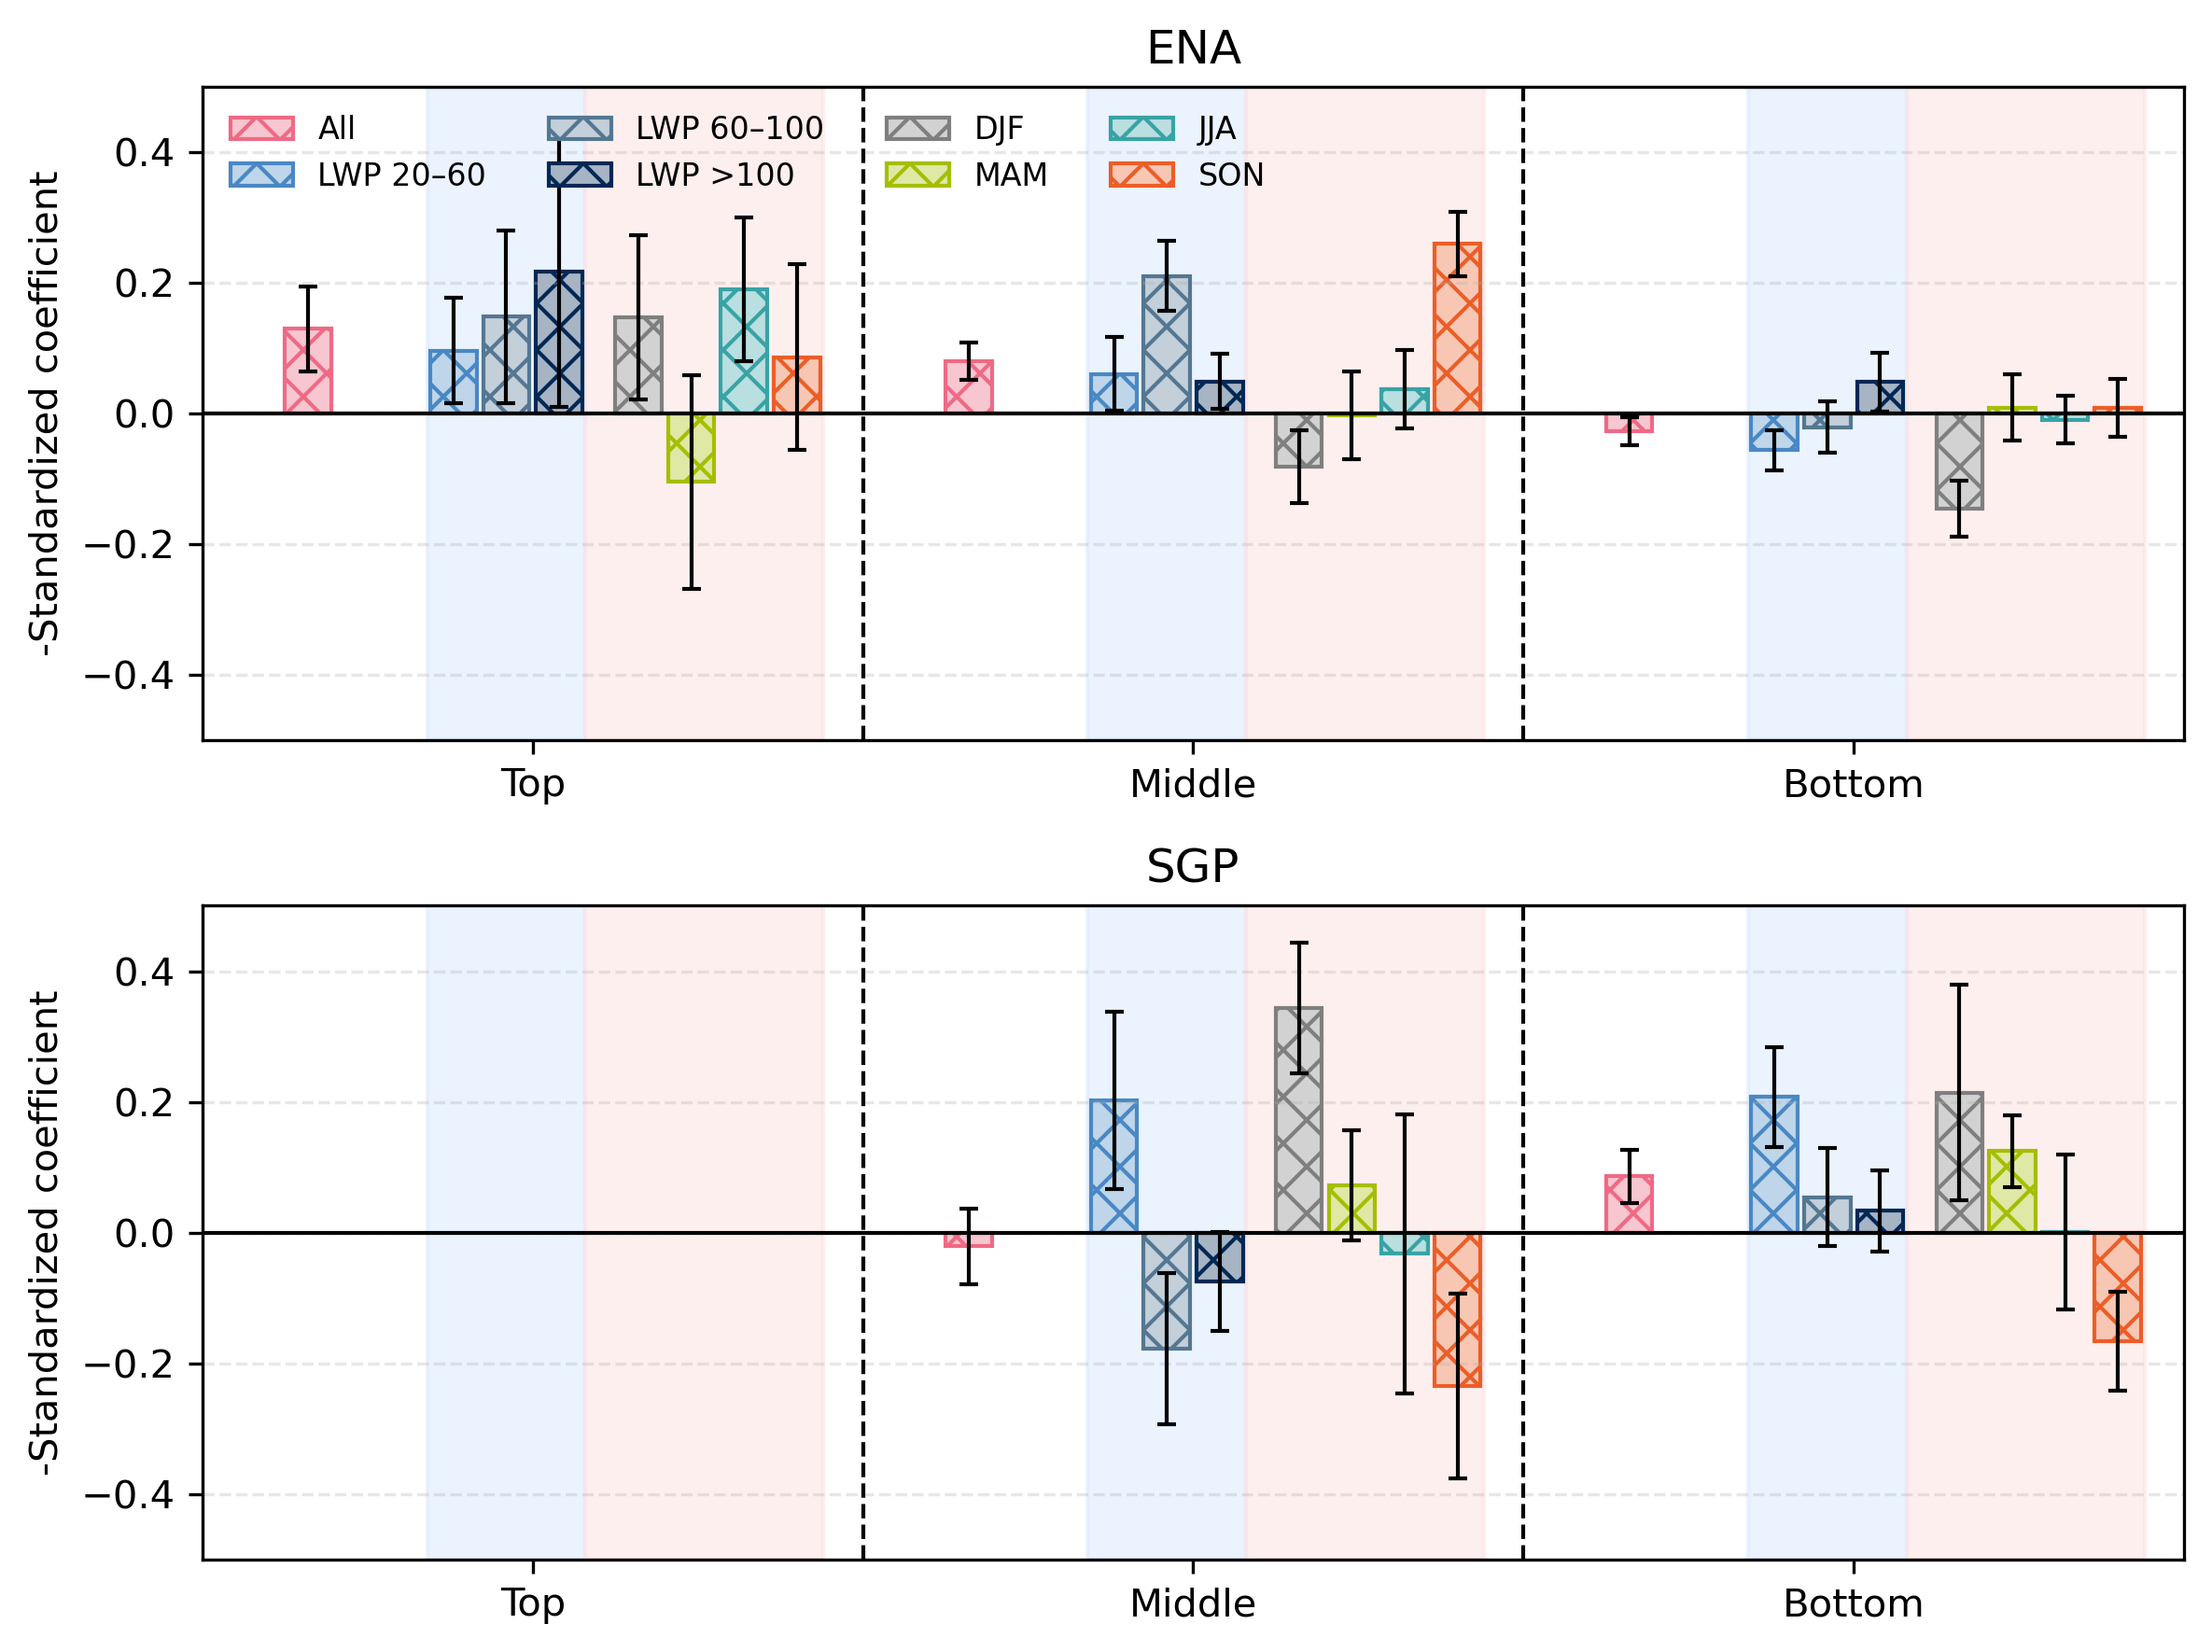

In [14]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.stats import linregress

cats, cat_labels = ["top", "middle", "bottom"], ["Top", "Middle", "Bottom"]
lwp_groups = [("20–60", lambda x:(x>=20)&(x<60)),
              ("60–100", lambda x:(x>=60)&(x<100)),
              (">100", lambda x:x>=100)]
seasons = ["DJF", "MAM", "JJA", "SON"]
m2s = {12:"DJF",1:"DJF",2:"DJF", 3:"MAM",4:"MAM",5:"MAM",
       6:"JJA",7:"JJA",8:"JJA", 9:"SON",10:"SON",11:"SON"}

lwp_cols = ["#4988C4", "#547792", "#002855"]
sea_cols = ["#7f7f7f", "#a5be00", "#38a3a5", "#eb5e28"]
dod_min, dod_max, min_count = 1e-6, 5e-1, 20

def lighten(c, a=0.65):
    rgb = np.array(mcolors.to_rgb(c))
    return tuple(rgb + (1 - rgb) * a)

def zscore(a):
    a = np.asarray(a, float)
    s = np.nanstd(a, ddof=1)
    return np.full_like(a, np.nan) if (not np.isfinite(s) or s == 0) else (a - np.nanmean(a)) / s

def slope_std(x, y):
    x, y = np.asarray(x, float), np.asarray(y, float)
    m = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0) & (x >= dod_min) & (x <= dod_max)
    x, y = x[m], y[m]
    if x.size < min_count: return np.nan, np.nan
    lx, ly = zscore(np.log(x)), zscore(np.log(y))
    m = np.isfinite(lx) & np.isfinite(ly)
    if m.sum() < min_count: return np.nan, np.nan
    r = linregress(lx[m], ly[m])
    return r.slope, r.stderr

def get_sens(df):
    d = df[["label", "month", "main_dod", "lwp", "Re"]].copy()
    d["label"] = d["label"].astype(str).str.lower()
    d["month"] = pd.to_numeric(d["month"], errors="coerce")
    d["season"] = d["month"].map(m2s)

    allv, allse = np.full(3, np.nan), np.full(3, np.nan)
    lwpv, lwpse = np.full((3, 3), np.nan), np.full((3, 3), np.nan)
    seav, sease = np.full((4, 3), np.nan), np.full((4, 3), np.nan)

    for j, c in enumerate(cats):
        dc = d[d["label"].eq(c)]
        dod, re, lwp = [dc[v].to_numpy(float) for v in ["main_dod", "Re", "lwp"]]

        s, se = slope_std(dod, re)
        if np.isfinite(s): allv[j], allse[j] = -s, se

        base = np.isfinite(dod) & np.isfinite(re) & np.isfinite(lwp) & (dod > 0) & (re > 0)
        for i, (_, cond) in enumerate(lwp_groups):
            s, se = slope_std(dod[base & cond(lwp)], re[base & cond(lwp)])
            if np.isfinite(s): lwpv[i, j], lwpse[i, j] = -s, se

        for i, ss in enumerate(seasons):
            ds = dc[dc["season"].eq(ss)]
            s, se = slope_std(ds["main_dod"], ds["Re"])
            if np.isfinite(s): seav[i, j], sease[i, j] = -s, se

    return allv, allse, lwpv, lwpse, seav, sease

ena = get_sens(df_ena_abs)
sgp = get_sens(df_sgp_abs)

fig, axes = plt.subplots(2, 1, figsize=(8, 6), dpi=300, sharey=True)

x, w = np.arange(3), 0.07
x_all = x - 0.34
x_lwp = [x - 0.12, x - 0.04, x + 0.04]
x_sea = [x + 0.16, x + 0.24, x + 0.32, x + 0.40]
errkw = dict(ecolor="k", elinewidth=1, capsize=2.5, capthick=1)

for ax, title, dat in zip(axes, ["ENA", "SGP"], [ena, sgp]):
    allv, allse, lwpv, lwpse, seav, sease = dat

    for xi in x:
        ax.axvspan(xi - 0.16, xi + 0.08, color="#dbeafe", alpha=0.55, zorder=0)  # LWP only
        ax.axvspan(xi + 0.08, xi + 0.44, color="#fee2e2", alpha=0.55, zorder=0)  # season only

    b0 = ax.bar(x_all, allv, w, yerr=allse, color="#f7c6d0", edgecolor="#ee6a85",
                lw=1, hatch="xx", error_kw=errkw, label="All")

    bl = [ax.bar(x_lwp[i], lwpv[i], w, yerr=lwpse[i],
                 color=lighten(lwp_cols[i]), edgecolor=lwp_cols[i],
                 lw=1, hatch="xx", error_kw=errkw, label=f"LWP {g[0]}")
          for i, g in enumerate(lwp_groups)]

    bs = [ax.bar(x_sea[i], seav[i], w, yerr=sease[i],
                 color=lighten(sea_cols[i]), edgecolor=sea_cols[i],
                 lw=1, hatch="xx", error_kw=errkw, label=ss)
          for i, ss in enumerate(seasons)]

    ax.axhline(0, color="k", lw=1)
    for xpos in [0.5, 1.5]:
        ax.axvline(xpos, color="k", lw=1, ls="--")

    ax.set(xlim=(-0.5, 2.5), ylim=(-0.5, 0.5),
           xticks=x, xticklabels=cat_labels,
           ylabel="-Standardized coefficient", title=title)
    ax.grid(axis="y", alpha=0.3, ls="--")

axes[0].legend(
    [b0, bl[0], bl[1], bl[2], bs[0], bs[1], bs[2], bs[3]],
    ["All", "LWP 20–60", "LWP 60–100", "LWP >100", "DJF", "MAM", "JJA", "SON"],
    frameon=False, ncol=4, loc="upper left", fontsize=8
)

plt.tight_layout()
plt.savefig("figsave/Figure3_lwp_season.pdf", dpi=300, bbox_inches="tight")
plt.show()

## Confounding influence of meteorology on dust-cloud interactions under different dust–cloud vertical configurations. Fig 4

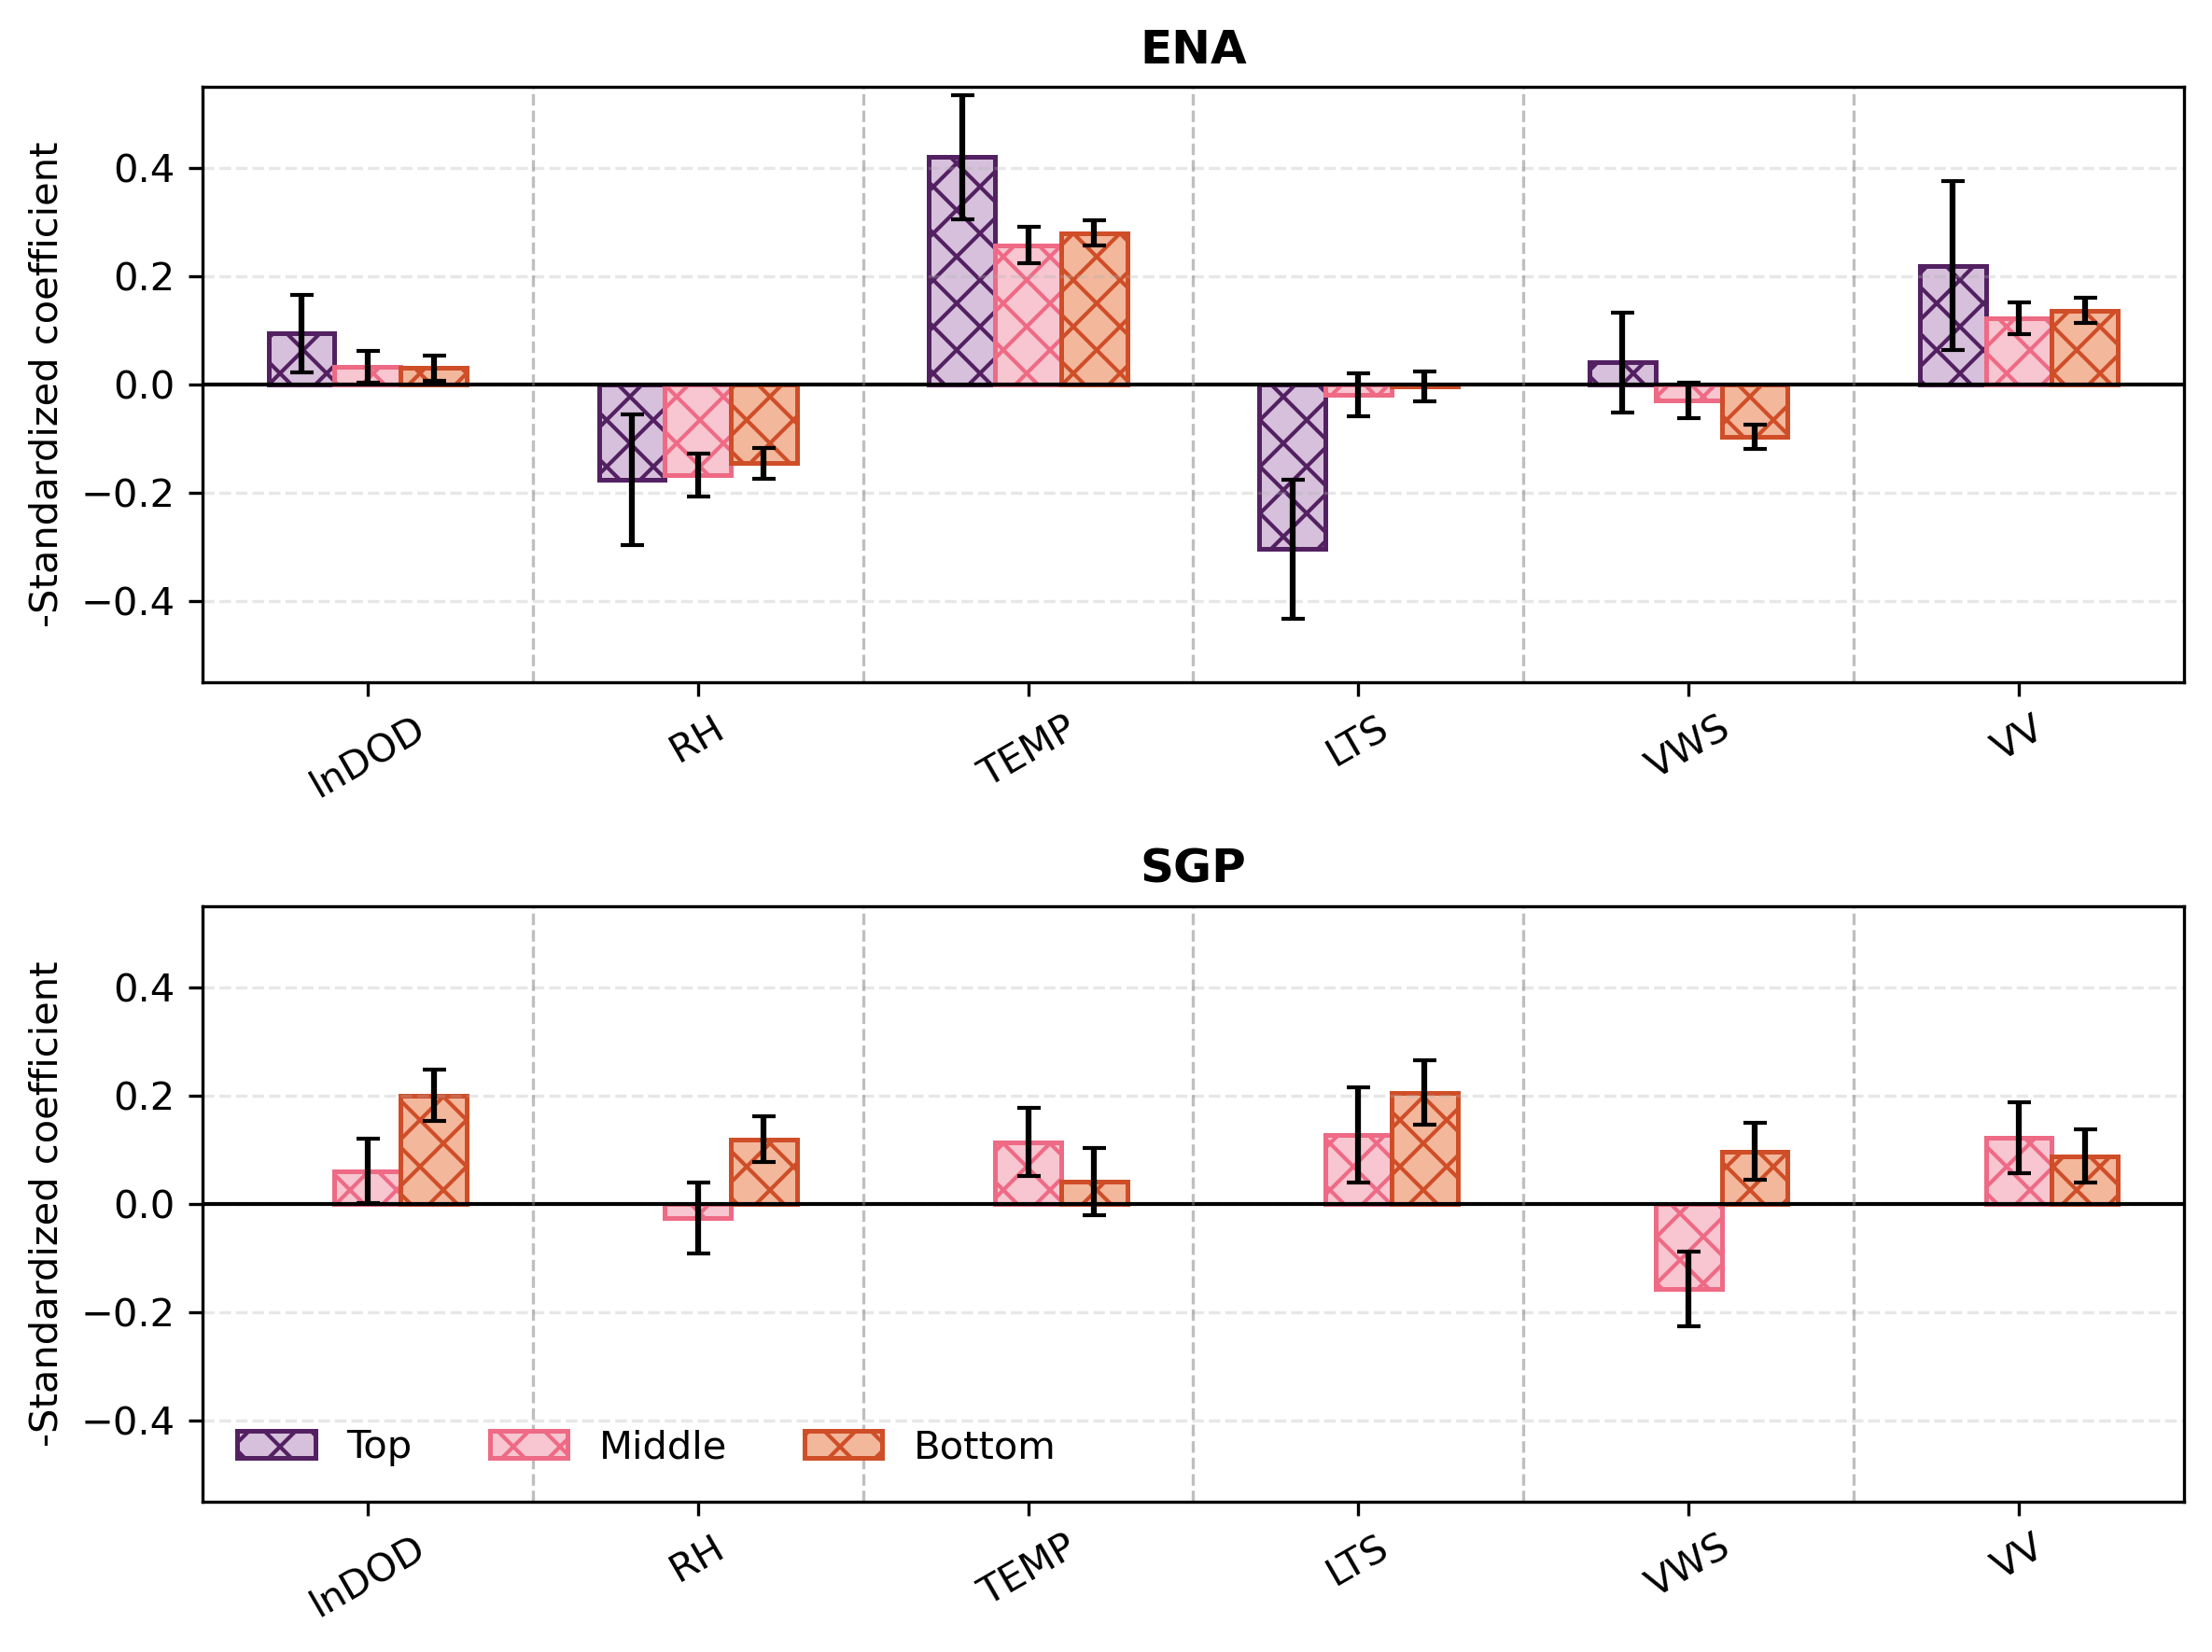


================== ENA ==================

--- top ---
       plot_coef      se       t       p
const    -0.2087  0.1388 -1.5034  0.1346
lnDOD     0.0942  0.0723  1.3024  0.1946
RH       -0.1758  0.1207 -1.4565  0.1471
TEMP      0.4202  0.1149  3.6584  0.0003
LTS      -0.3034  0.1282 -2.3660  0.0191
VWS       0.0412  0.0921  0.4479  0.6548
VV        0.2196  0.1563  1.4055  0.1617

--- middle ---
       plot_coef      se       t       p
const    -0.1023  0.0316 -3.2381  0.0012
lnDOD     0.0333  0.0294  1.1331  0.2575
RH       -0.1664  0.0394 -4.2219  0.0000
TEMP      0.2576  0.0332  7.7511  0.0000
LTS      -0.0193  0.0394 -0.4891  0.6249
VWS      -0.0295  0.0323 -0.9123  0.3618
VV        0.1230  0.0290  4.2344  0.0000

--- bottom ---
       plot_coef      se        t       p
const     0.1553  0.0216   7.1783  0.0000
lnDOD     0.0305  0.0229   1.3319  0.1830
RH       -0.1448  0.0286  -5.0559  0.0000
TEMP      0.2795  0.0233  11.9785  0.0000
LTS      -0.0030  0.0280  -0.1072  0.9147
VWS 

In [7]:
import numpy as np, pandas as pd, statsmodels.api as sm, matplotlib.pyplot as plt

met_vars = ["RH", "TEMP", "LTS", "VWS", "VV"]
cats = ["top", "middle", "bottom"]
vars_all = ["lnDOD"] + met_vars
cols = ["#d6c0db", "#f7c6d0", "#f3b79c"]
edges = ["#532162", "#ee6a85", "#cf4e28"]

def safe_log(x):
    x = pd.to_numeric(x, errors="coerce").astype(float)
    return np.log(x.where(x > 0))

def prep_df(df):
    d = df[["label", "Re", "main_dod"] + met_vars].copy()
    d["lnRe"], d["lnDOD"] = safe_log(d["Re"]), safe_log(d["main_dod"])
    d = d.drop(columns=["Re", "main_dod"]).replace([np.inf, -np.inf], np.nan)
    for v in ["lnRe", "lnDOD"] + met_vars:
        s = d[v].std(skipna=True)
        d[v] = (d[v] - d[v].mean(skipna=True)) / s if np.isfinite(s) and s > 0 else np.nan
    return d

def fit_site(df, min_n=15):
    d, out = prep_df(df), {}
    for c in cats:
        dc = d[d["label"].eq(c)][["lnRe"] + vars_all].dropna()
        out[c] = None if len(dc) < min_n else sm.OLS(dc["lnRe"], sm.add_constant(dc[vars_all])).fit()
    return out

res_ena, res_sgp = fit_site(df_ena_abs), fit_site(df_sgp_abs)

fig, axes = plt.subplots(2, 1, figsize=(8, 6), dpi=300, sharey=True)
x, w = np.arange(len(vars_all)), 0.2

for ax, res, site in zip(axes, [res_ena, res_sgp], ["ENA", "SGP"]):
    for i, c in enumerate(cats):
        if res[c] is None:
            vals = errs = np.full(len(vars_all), np.nan)
        else:
            vals = -res[c].params.reindex(vars_all).values
            errs = res[c].bse.reindex(vars_all).values
        ax.bar(x + (i - 1) * w, vals, w, yerr=errs, capsize=3, color=cols[i], edgecolor=edges[i], lw=1.2, hatch="xx", label=c.capitalize())
    ax.axhline(0, lw=1, color="k")
    ax.set_xlim(-0.5, len(vars_all) - 0.5)
    ax.set_ylim(-0.55, 0.55)
    
    for xpos in x[:-1] + 0.5:
        ax.axvline(xpos, ymin=0, ymax=1, ls="--", lw=0.8, color="gray", alpha=0.5)
    ax.set_xticks(x); ax.set_xticklabels(vars_all, rotation=30)
    ax.set_ylabel("-Standardized coefficient"); ax.set_title(site, weight="bold")
    ax.grid(axis="y", ls="--", alpha=0.3)

axes[1].legend(frameon=False, ncol=3)
plt.tight_layout()
plt.savefig("figsave/METE.pdf", dpi=300, bbox_inches="tight")
plt.show()

for site, res in zip(["ENA", "SGP"], [res_ena, res_sgp]):
    print(f"\n{'='*18} {site} {'='*18}")
    for c in cats:
        print(f"\n--- {c} ---")
        if res[c] is None:
            print("Not enough samples"); continue
        out = pd.DataFrame({"plot_coef": -res[c].params, "se": res[c].bse, "t": -res[c].tvalues, "p": res[c].pvalues}).loc[["const"] + vars_all]
        print(out.round(4))

site category  dust_aci_without_met  without_met_se  dust_aci_with_met  with_met_se  difference  difference_se  n_without_met  n_with_met
 ENA      top                0.1298          0.0650             0.0924       0.0709      0.0374         0.0962            235         175
 ENA   middle                0.0797          0.0286             0.0348       0.0307      0.0449         0.0420           1216         948
 ENA   bottom               -0.0264          0.0213             0.0287       0.0215     -0.0551         0.0303           2205        1920
 SGP      top                   NaN             NaN                NaN          NaN         NaN            NaN              8           5
 SGP   middle               -0.0210          0.0574             0.0675       0.0664     -0.0885         0.0878            305         235
 SGP   bottom                0.0862          0.0405             0.1897       0.0444     -0.1035         0.0601            607         524


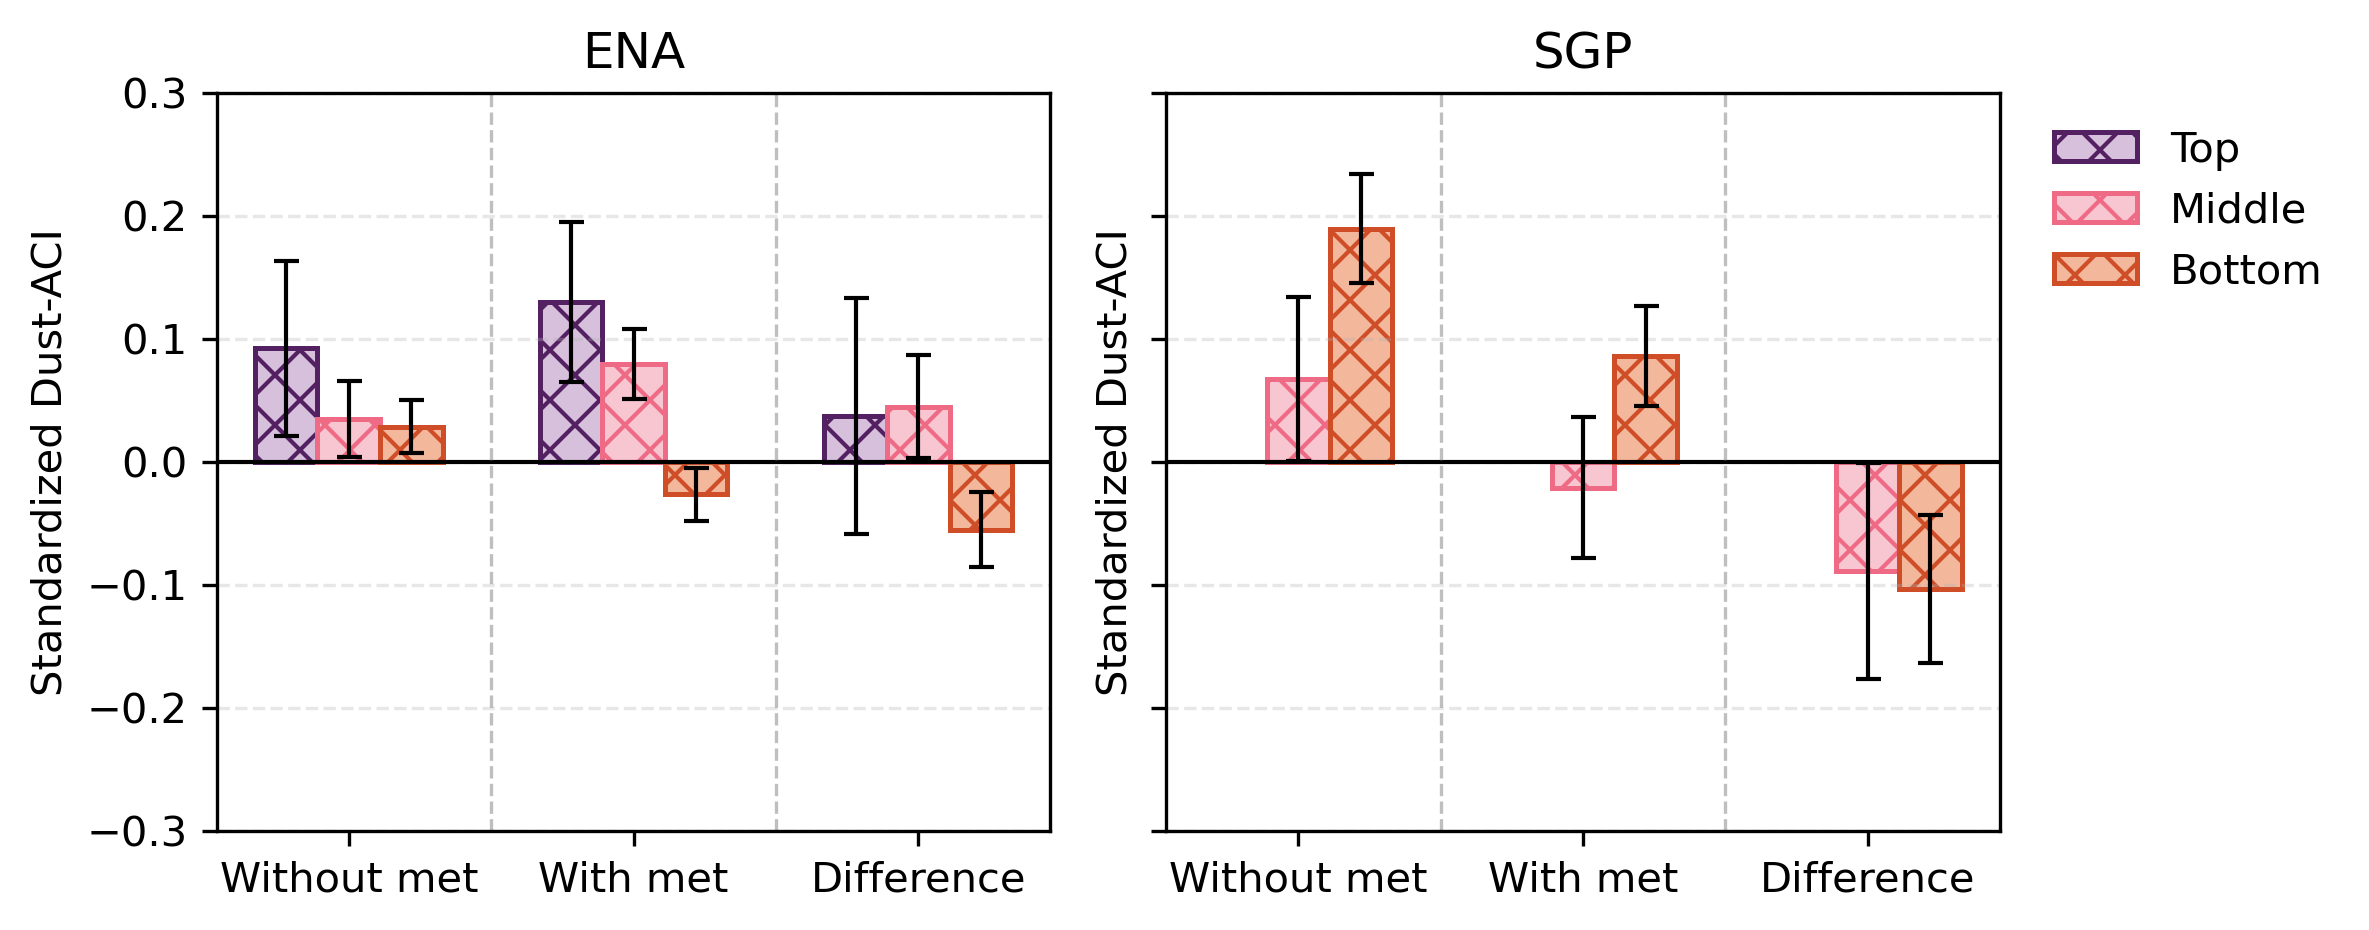

In [8]:
import numpy as np, pandas as pd, statsmodels.api as sm, matplotlib.pyplot as plt
from scipy.stats import linregress

# ---------- Load data ----------
df_ena_abs = pd.read_csv("/data/ggong/ARM_monthly/ENA/csv_file/df_abs.csv")
df_sgp_abs = pd.read_csv("/data/ggong/ARM_monthly/SGP/csv_file/df_abs.csv")

# ---------- Settings ----------
cats, cat_labels = ["top", "middle", "bottom"], ["Top", "Middle", "Bottom"]
met_vars = ["RH", "TEMP", "LTS", "VWS", "VV"]
cols, edges = ["#d6c0db", "#f7c6d0", "#f3b79c"], ["#532162", "#ee6a85", "#cf4e28"]
dod_min, dod_max, min_count, min_n = 1e-6, 5e-1, 20, 15

def zscore(x):
    x = np.asarray(x, float)
    s = np.nanstd(x, ddof=1)
    return (x - np.nanmean(x)) / s if np.isfinite(s) and s > 0 else np.full_like(x, np.nan)

def safe_log(x):
    x = pd.to_numeric(x, errors="coerce").to_numpy(float)
    x[x <= 0] = np.nan
    return np.log(x)

def prep(df):
    d = df.copy()
    d["label"] = d["label"].astype(str).str.lower()
    return d[d["label"].isin(cats)]

def aci_raw(dc):
    x = pd.to_numeric(dc["main_dod"], errors="coerce").to_numpy(float)
    y = pd.to_numeric(dc["Re"], errors="coerce").to_numpy(float)
    m = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0) & (dod_min <= x) & (x <= dod_max)
    x, y = x[m], y[m]
    if x.size < min_count: return np.nan, np.nan, x.size
    x, y = zscore(np.log(x)), zscore(np.log(y))
    m = np.isfinite(x) & np.isfinite(y)
    if m.sum() < min_count: return np.nan, np.nan, int(m.sum())
    r = linregress(x[m], y[m])
    return -r.slope, r.stderr, int(m.sum())

def aci_met(dc):
    d = dc[["Re", "main_dod"] + met_vars].copy()
    d["lnRe"], d["lnDOD"] = safe_log(d["Re"]), safe_log(d["main_dod"])
    d = d.drop(columns=["Re", "main_dod"]).replace([np.inf, -np.inf], np.nan)

    for v in ["lnRe", "lnDOD"]:
        s = d[v].std(skipna=True)
        d[v] = (d[v] - d[v].mean(skipna=True)) / s if np.isfinite(s) and s > 0 else np.nan

    for v in met_vars:
        d[v] = pd.to_numeric(d[v], errors="coerce")

    d = d[["lnRe", "lnDOD"] + met_vars].dropna()
    if len(d) < min_n: return np.nan, np.nan, len(d)

    fit = sm.OLS(d["lnRe"], sm.add_constant(d[["lnDOD"] + met_vars])).fit()
    return -fit.params["lnDOD"], fit.bse["lnDOD"], len(d)

def calc_site(df, site):
    rows, d = [], prep(df)
    for c in cats:
        dc = d[d["label"].eq(c)]
        raw, raw_se, n_raw = aci_raw(dc)
        met, met_se, n_met = aci_met(dc)
        diff = raw - met
        diff_se = np.sqrt(raw_se**2 + met_se**2) if np.isfinite(raw_se) and np.isfinite(met_se) else np.nan
        rows.append([site, c, raw, raw_se, met, met_se, diff, diff_se, n_raw, n_met])
    return pd.DataFrame(rows, columns=[
        "site", "category",
        "dust_aci_without_met", "without_met_se",
        "dust_aci_with_met", "with_met_se",
        "difference", "difference_se",
        "n_without_met", "n_with_met"
    ])

df_mean = pd.concat([calc_site(df_ena_abs, "ENA"), calc_site(df_sgp_abs, "SGP")], ignore_index=True)
print(df_mean.round(4).to_string(index=False))
df_mean.to_csv("figsave/dust_aci_with_without_met_mean_numbers.csv", index=False)

metrics = [
    ("dust_aci_with_met", "with_met_se", "Without met"),
    ("dust_aci_without_met", "without_met_se", "With met"),
    ("difference", "difference_se", "Difference")
]

x, w = np.arange(len(metrics)), 0.22
errkw = dict(ecolor="k", elinewidth=1, capsize=3, capthick=1)

fig, axes = plt.subplots(1, 2, figsize=(8, 3.2), dpi=300, sharex=True, sharey=True)

for ax, site in zip(axes, ["ENA", "SGP"]):
    ds = df_mean[df_mean["site"].eq(site)]
    for i, c in enumerate(cats):
        r = ds[ds["category"].eq(c)].iloc[0]
        y = [r[m[0]] for m in metrics]
        e = [r[m[1]] for m in metrics]
        ax.bar(x + (i - 1) * w, y, w, yerr=e, color=cols[i], edgecolor=edges[i],
               lw=1.2, hatch="xx", error_kw=errkw, label=cat_labels[i])

    ax.axhline(0, color="k", lw=1)
    ax.vlines(x[:-1] + 0.5, -0.3, 0.3, color="gray", lw=0.8, ls="--", alpha=0.5)
    ax.set_ylim(-0.3, 0.3)
    ax.set_xticks(x)
    ax.set_xticklabels([m[2] for m in metrics])
    ax.set_ylabel("Standardized Dust-ACI")
    ax.set_title(site)
    ax.grid(axis="y", ls="--", alpha=0.3)

axes[1].legend(frameon=False, ncol=1, loc="upper left", bbox_to_anchor=(1.02, 1.0))
plt.tight_layout()
plt.savefig("figsave/dust_aci_with_without_met_mean_difference.pdf", dpi=300, bbox_inches="tight")
plt.show()

# Extra analysis

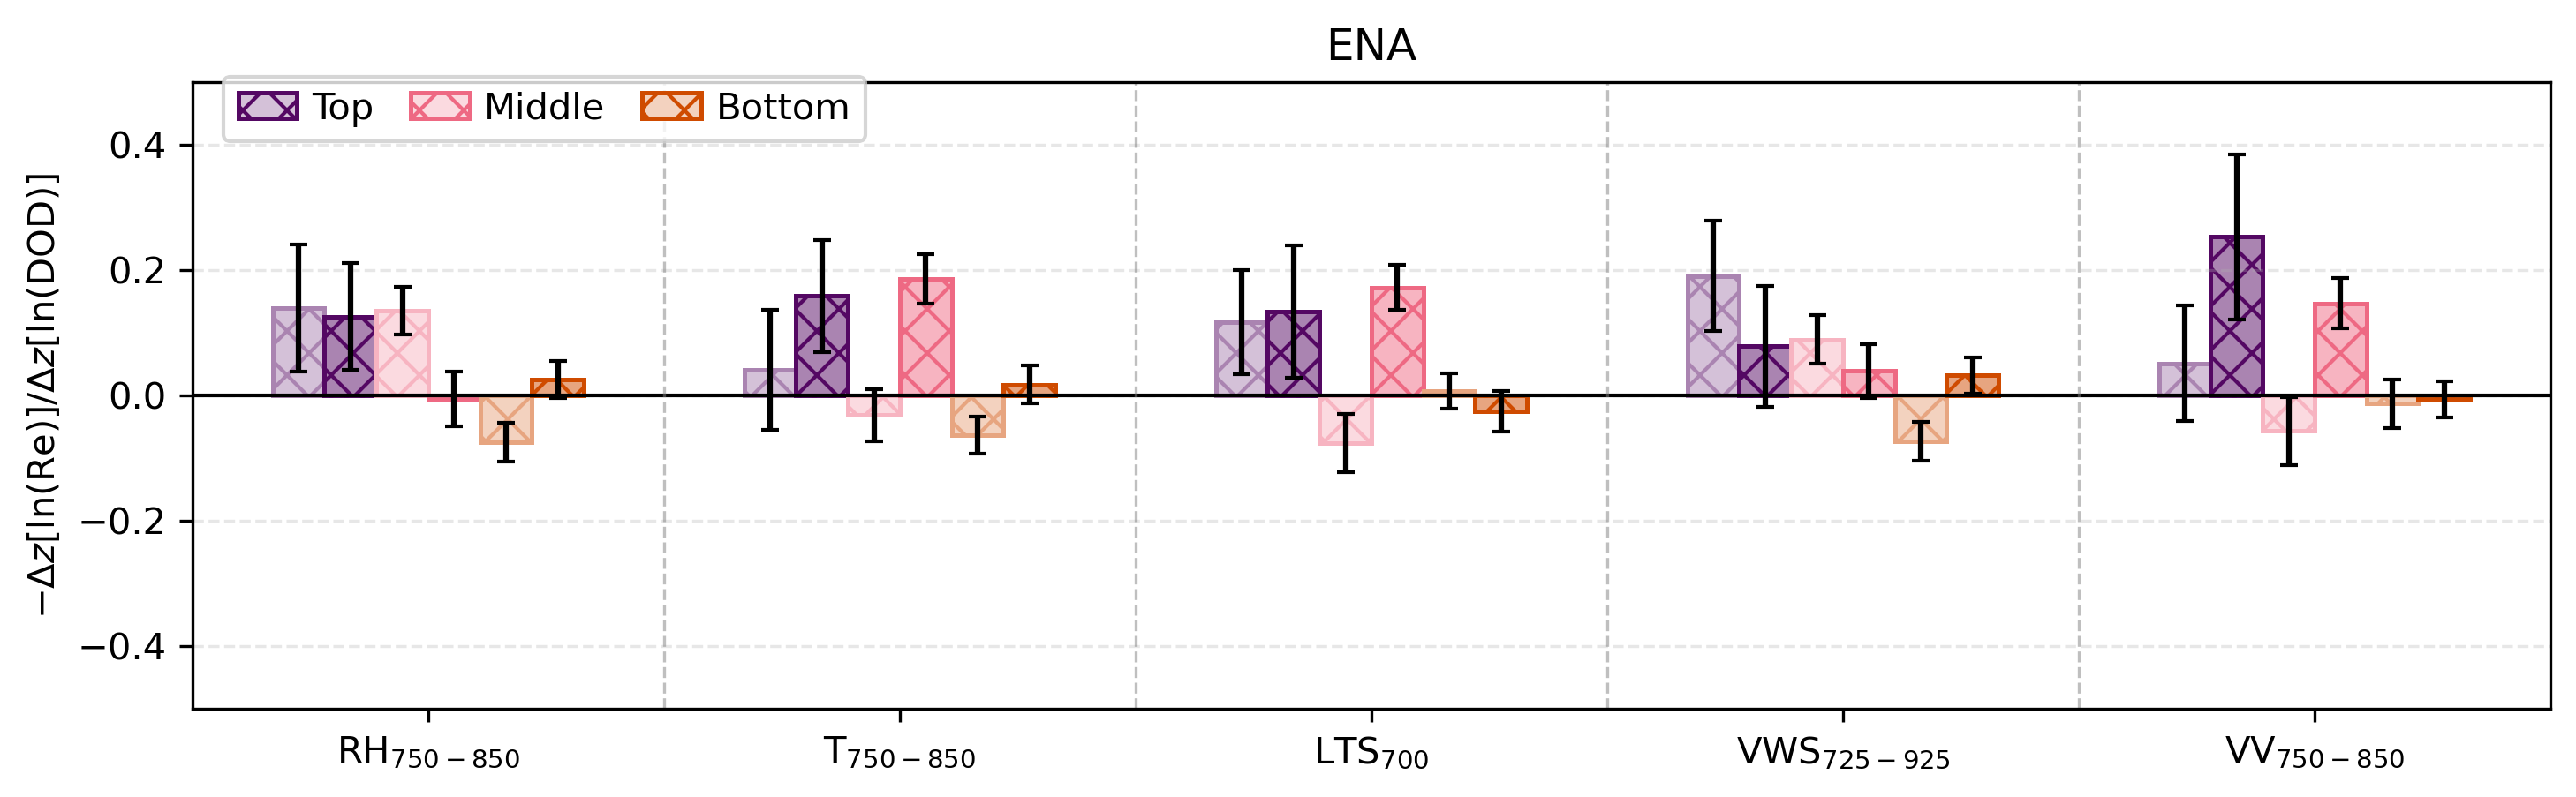

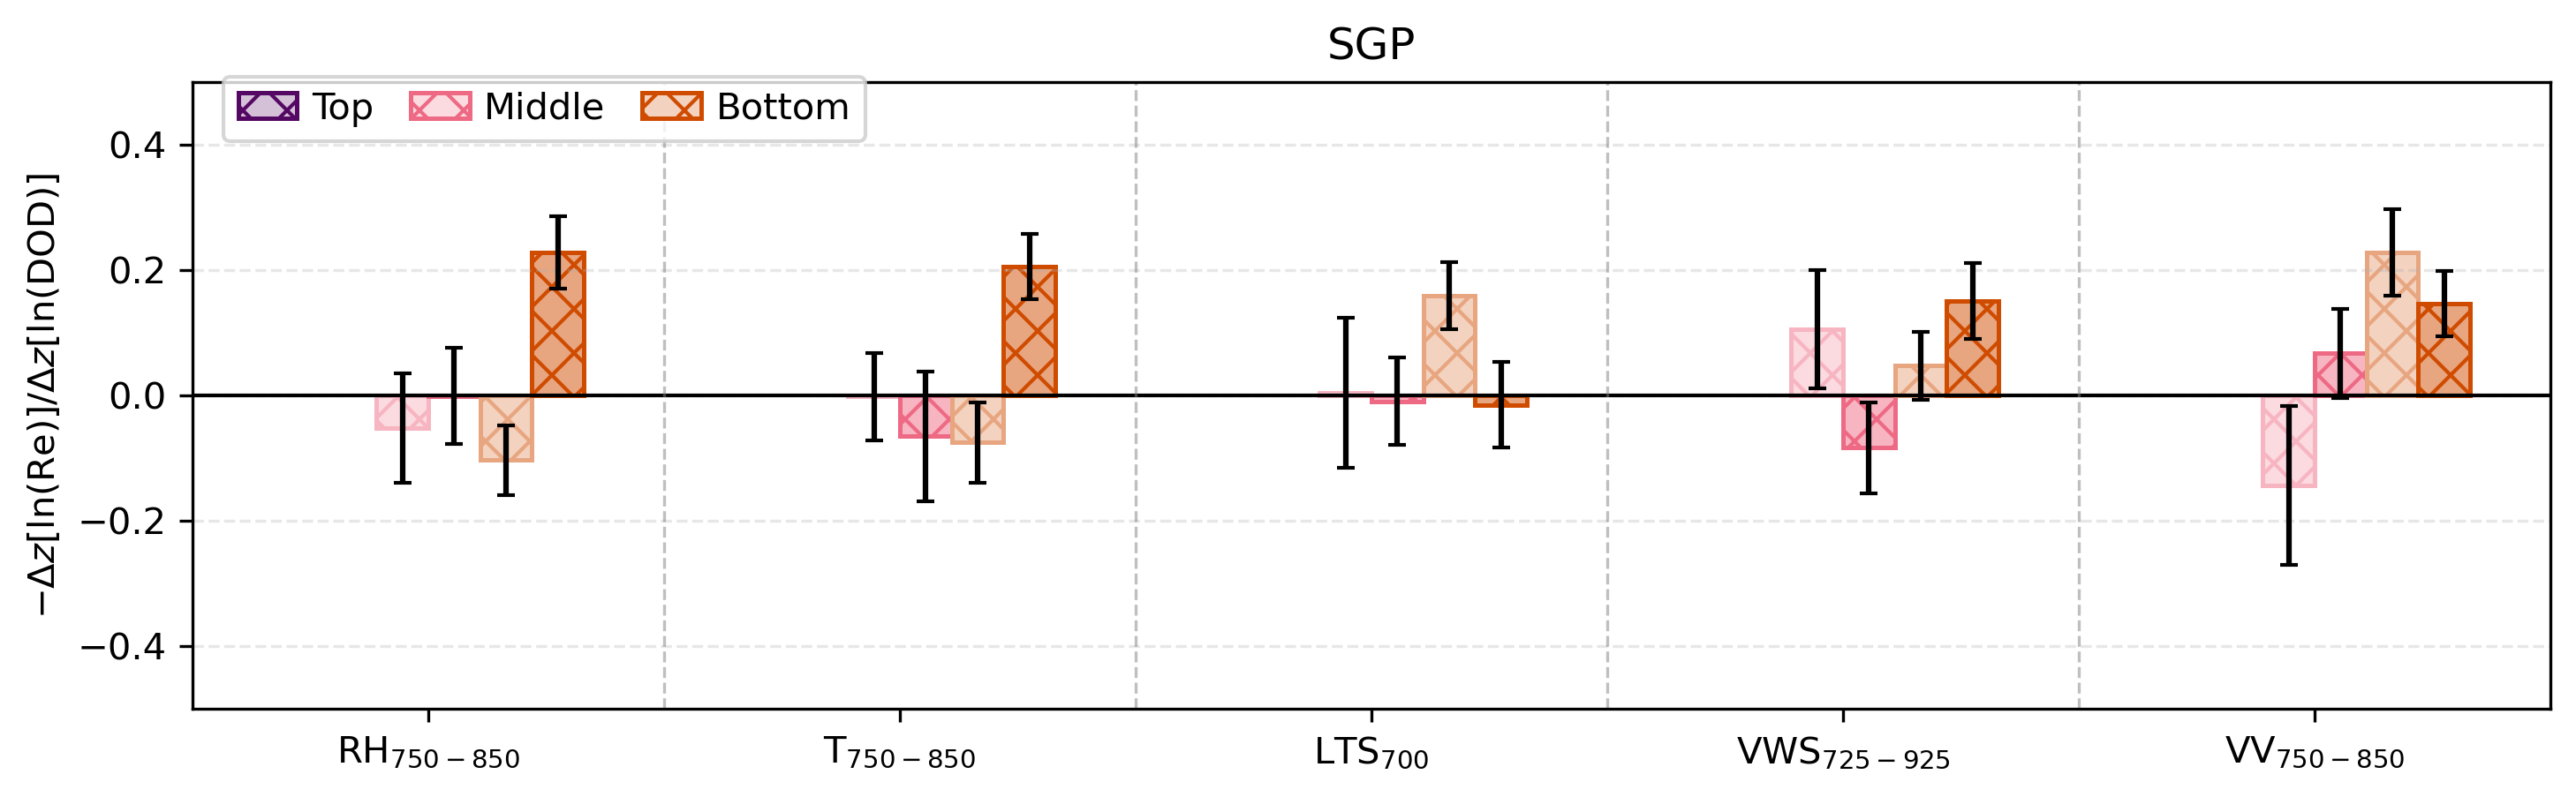

In [9]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, matplotlib.colors as mcolors
from scipy.stats import linregress
from matplotlib.patches import Patch

# -----------------------------
# Settings
# -----------------------------
cats, cat_labels = ["top", "middle", "bottom"], ["Top", "Middle", "Bottom"]
base_cols = ["#540863", "#EE6983", "#CF4B00"]
met_vars = ["RH", "TEMP", "LTS", "VWS", "VV"]
xlabels = {"RH": "RH$_{750-850}$", "TEMP": "T$_{750-850}$", "LTS": "LTS$_{700}$",
           "VWS": "VWS$_{725-925}$", "VV": "VV$_{750-850}$"}
dod_min, dod_max, min_count = 1e-6, 5e-1, 20

# -----------------------------
# Helper functions
# -----------------------------
def lighten(c, a=0.5):
    rgb = np.array(mcolors.to_rgb(c))
    return tuple(rgb + (1 - rgb) * a)

def zscore(x):
    x = np.asarray(x, float)
    s = np.nanstd(x, ddof=1)
    return (x - np.nanmean(x)) / s if np.isfinite(s) and s > 0 else np.full_like(x, np.nan)

def calc_slope_se_std(dod, re):
    dod, re = np.asarray(dod, float), np.asarray(re, float)
    m = np.isfinite(dod) & np.isfinite(re) & (dod > 0) & (re > 0) & (dod_min <= dod) & (dod <= dod_max)
    dod, re = dod[m], re[m]
    if dod.size < min_count:
        return np.nan, np.nan, dod.size

    x, y = zscore(np.log(dod)), zscore(np.log(re))
    mm = np.isfinite(x) & np.isfinite(y)
    if mm.sum() < min_count:
        return np.nan, np.nan, int(mm.sum())

    r = linregress(x[mm], y[mm])
    return -r.slope, r.stderr, int(mm.sum())

# -----------------------------
# Main plotting function
# -----------------------------
def plot_common_threshold_from_df_std(df, site_name="ENA", savepath=None):
    d = df[["label", "Re", "main_dod"] + met_vars].copy()
    d = d[d["label"].isin(cats)].replace([np.inf, -np.inf], np.nan)

    # Common threshold: median of all categories combined; VV uses 0
    thresholds = {v: 0.0 if v == "VV" else np.nanmedian(pd.to_numeric(d[v], errors="coerce")) for v in met_vars}
    results = []

    fig, ax = plt.subplots(figsize=(10, 3.2), dpi=300)
    centers, bar_w = np.arange(len(met_vars)), 0.11
    offsets = np.array([-2.5, -1.5, -0.5, 0.5, 1.5, 2.5]) * bar_w

    for k, v in enumerate(met_vars):
        thr = thresholds[v]
        # print(f"\n===== {site_name} | {v} =====")

        for j, c in enumerate(cats):
            dc = d[d["label"].eq(c)]
            dod = pd.to_numeric(dc["main_dod"], errors="coerce").to_numpy(float)
            re = pd.to_numeric(dc["Re"], errors="coerce").to_numpy(float)
            met = pd.to_numeric(dc[v], errors="coerce").to_numpy(float)

            m = np.isfinite(dod) & np.isfinite(re) & np.isfinite(met) & (dod > 0) & (re > 0)
            dod, re, met = dod[m], re[m], met[m]

            groups = [met < 0, met >= 0] if v == "VV" else [met < thr, met >= thr]
            gnames = ["<0", "≥0"] if v == "VV" else ["low", "high"]

            ec = [lighten(base_cols[j], 0.5), base_cols[j]]
            fc = [lighten(ec[0], 0.5), lighten(ec[1], 0.5)]

            for i, (gname, mm) in enumerate(zip(gnames, groups)):
                slope, se, n = calc_slope_se_std(dod[mm], re[mm])
                results.append([site_name, v, c, gname, thr, slope, se, n])
                # print(f"{c:>6} | {gname:>4} | thr={thr:.3f} | std_slope={slope:.4f} | se={se:.4f} | n={n}")
                ax.bar(centers[k] + offsets[j * 2 + i], slope, bar_w, yerr=se, capsize=2.5,
                       facecolor=fc[i], edgecolor=ec[i], lw=1.2, hatch="xx")

    # -----------------------------
    # Figure formatting
    # -----------------------------
    bounds = np.r_[centers[0] - 0.5, (centers[:-1] + centers[1:]) / 2, centers[-1] + 0.5]
    ax.axhline(0, color="k", lw=1)
    ax.vlines(bounds[1:-1], -0.5, 0.5, color="gray", lw=0.8, ls="--", alpha=0.5)
    ax.set(xlim=(bounds[0], bounds[-1]), ylim=(-0.5, 0.5), xticks=centers,
           xticklabels=[xlabels[v] for v in met_vars],
           ylabel=r"$-\Delta z[\ln(\mathrm{Re})] / \Delta z[\ln(\mathrm{DOD})]$",
           title=site_name)
    ax.grid(axis="y", ls="--", alpha=0.3)

    ax.legend(handles=[Patch(facecolor=lighten(lighten(c, 0.5), 0.5), edgecolor=c, hatch="xx", label=l, lw=1.2)
                       for c, l in zip(base_cols, cat_labels)],
              loc="upper left", ncol=3, frameon=True, bbox_to_anchor=(0.01, 1.02),
              borderaxespad=0.2, handlelength=1.6, handletextpad=0.4, columnspacing=1.0)

    plt.subplots_adjust(left=0.09, right=0.98, bottom=0.16, top=0.90)
    if savepath:
        fig.savefig(savepath, dpi=300, bbox_inches="tight")
    plt.show()

    return pd.DataFrame(results, columns=["site", "variable", "category", "group", "threshold", "std_slope", "stderr", "n"])

# -----------------------------
# Run ENA
# -----------------------------
df_res_ena_std = plot_common_threshold_from_df_std(df_ena_abs, "ENA", "figsave/mete_ENA_common_threshold_std.pdf")
df_res_sgp_std = plot_common_threshold_from_df_std(df_sgp_abs, "SGP", "figsave/mete_SGP_common_threshold_std.pdf")
pd.set_option("display.precision", 4)
# print("\nFull ENA standardized results:\n")
# print(df_res_ena_std.to_string(index=False))

## All variable

## climatoloty

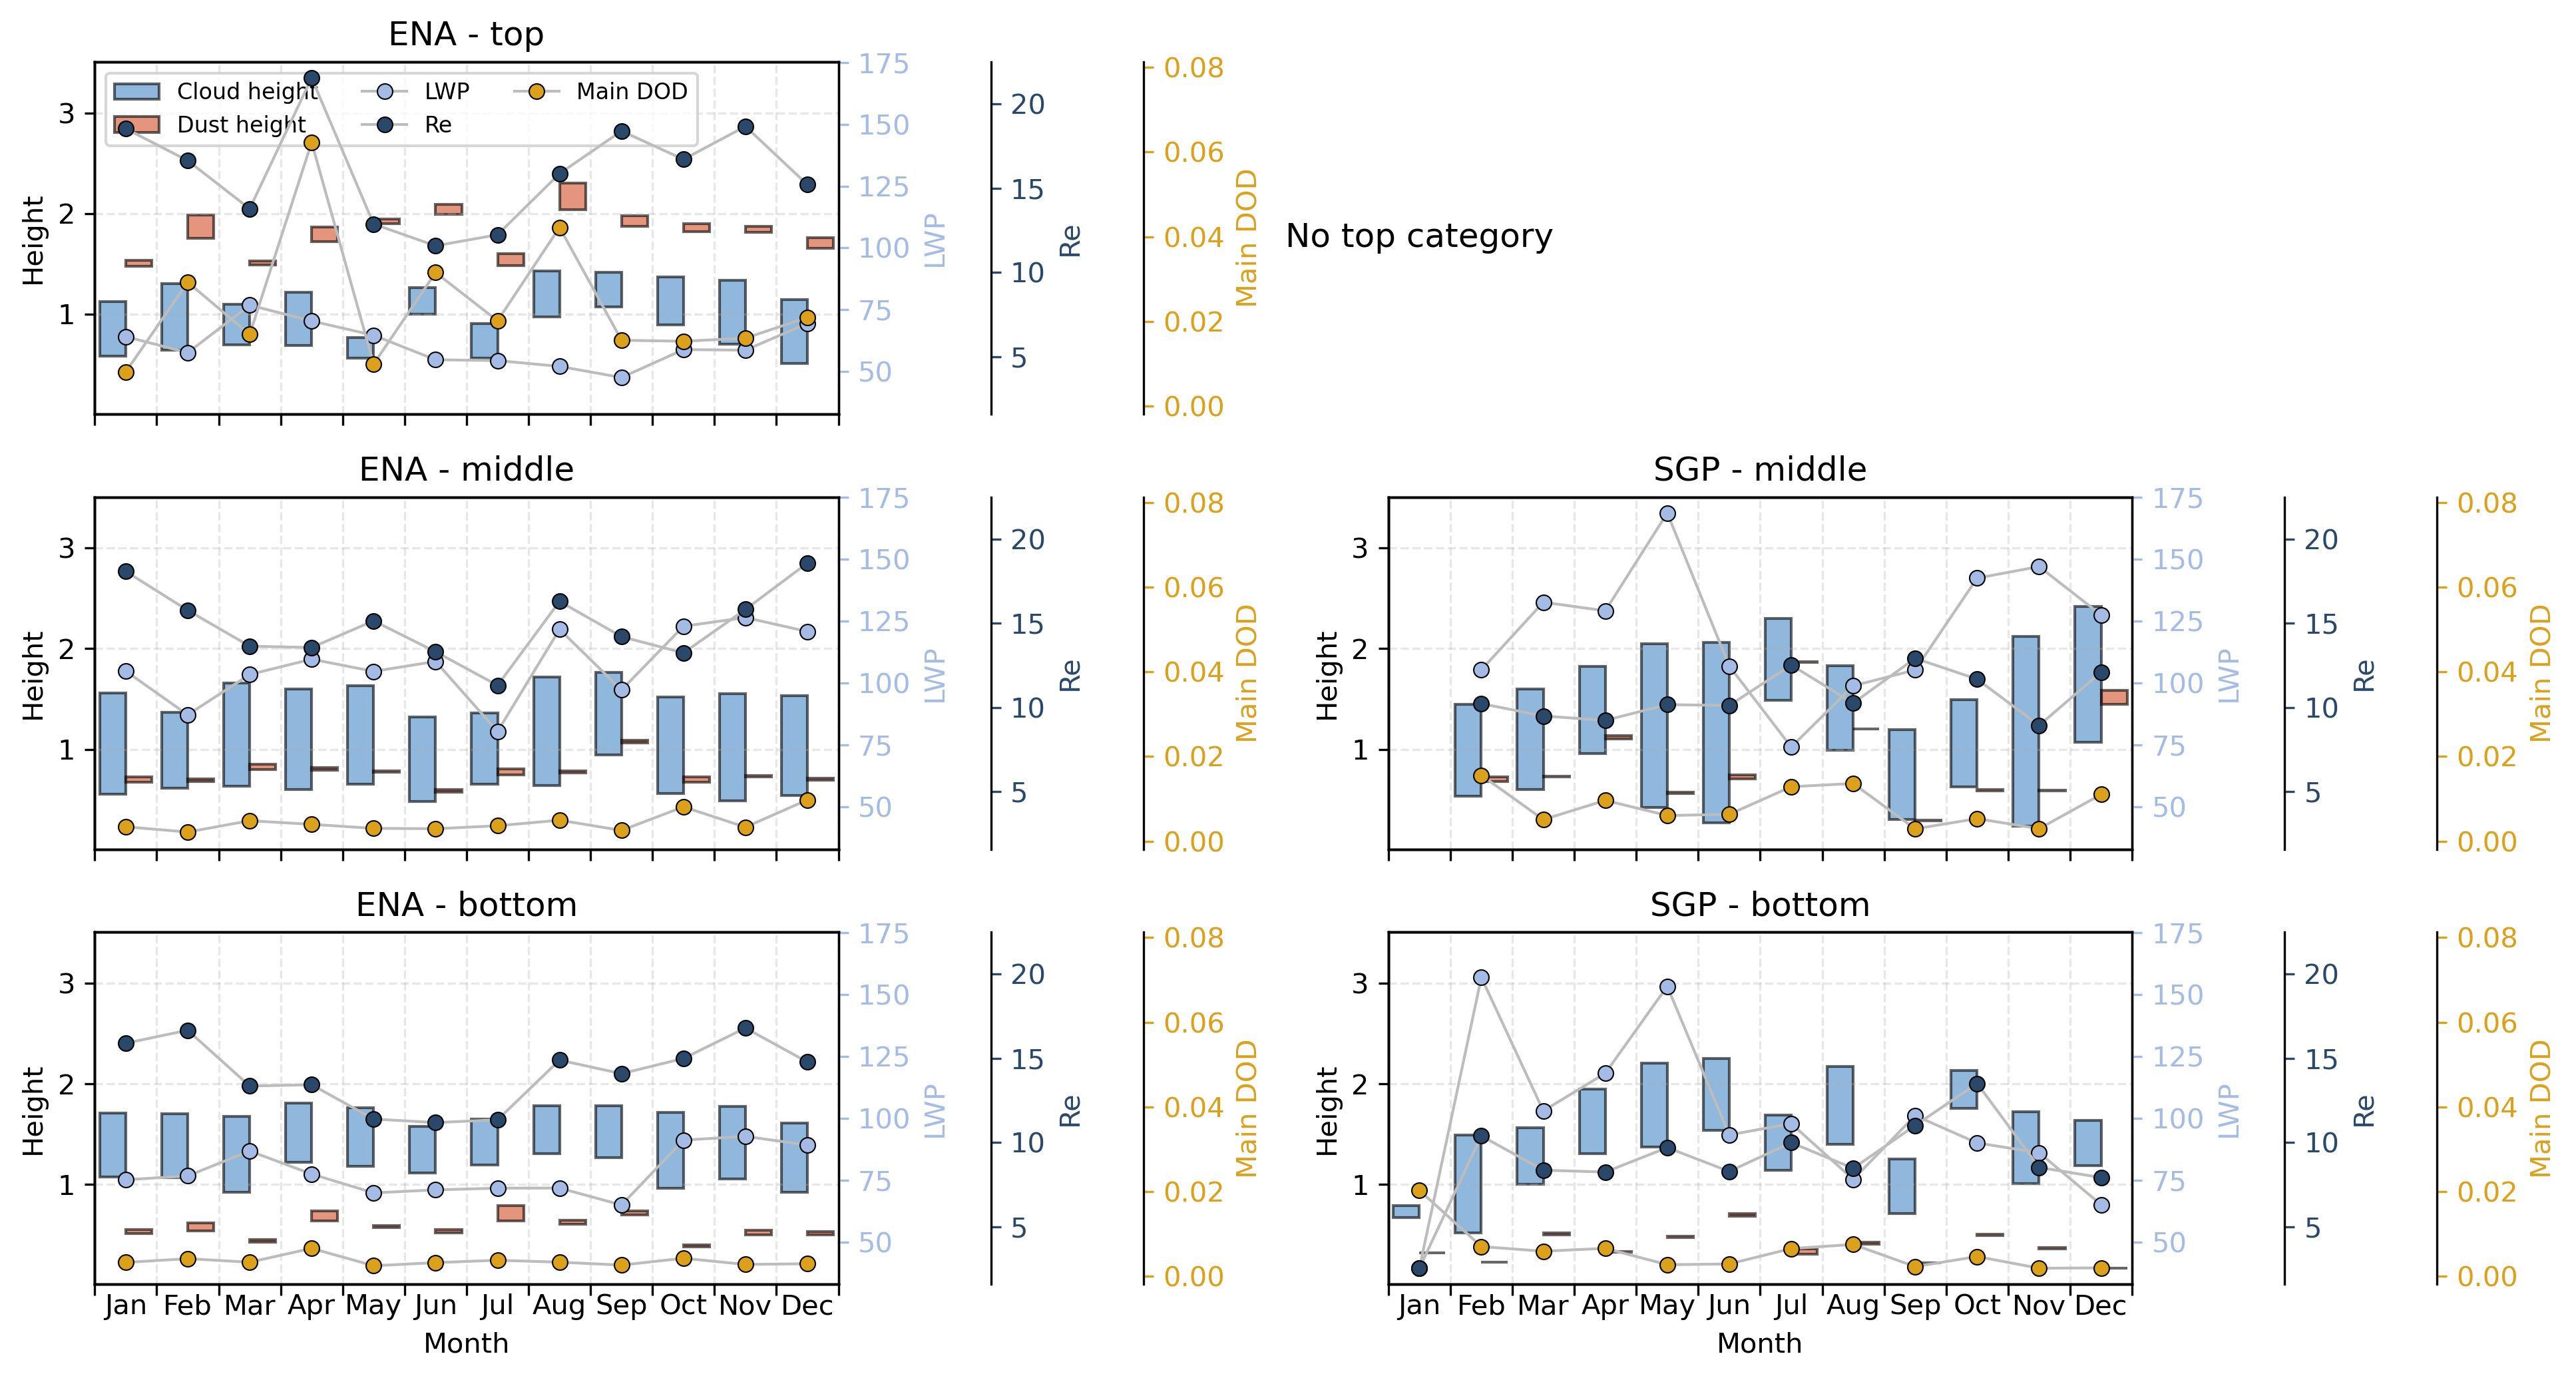

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

cols = ['label','month','cloud_th','dust_th','cloud_bh','dust_bh','lwp','Re','main_dod']
order = ['top', 'middle', 'bottom']
months = np.arange(1, 13)
x_tick = np.arange(13)
x_mid = np.arange(12) + 0.5
xtlabs = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

def prep(df):
    df = df[cols].copy()
    df['month'] = pd.to_numeric(df['month'])
    return df.groupby(['label','month'], as_index=False).mean(numeric_only=True)

ena_m = prep(df_ena_abs)
sgp_m = prep(df_sgp_abs)
all_m = pd.concat([ena_m, sgp_m], ignore_index=True)

def lim(s, p=0.05):
    vmin, vmax = np.nanmin(s), np.nanmax(s)
    pad = (vmax - vmin) * p if vmax > vmin else 1
    return vmin - pad, vmax + pad

height_ylim = lim(all_m[['cloud_bh','dust_bh','cloud_th','dust_th']].values.ravel())
lwp_ylim = lim(all_m['lwp'])
re_ylim  = lim(all_m['Re'])
dod_ylim = lim(all_m['main_dod'])

def draw(ax, df_m, lab, title=None, show_legend=False):
    sub = df_m[df_m['label'].eq(lab)].set_index('month').reindex(months).reset_index()

    ax_lwp, ax_re, ax_dod = ax.twinx(), ax.twinx(), ax.twinx()
    ax_re.spines['right'].set_position(('outward', 55))
    ax_dod.spines['right'].set_position(('outward', 110))
    for a in [ax_re, ax_dod]:
        a.set_frame_on(True)
        a.patch.set_visible(False)

    bw = 0.42

    b1 = ax.bar(x_mid - bw/2, sub['cloud_th'] - sub['cloud_bh'], bottom=sub['cloud_bh'],
                width=bw, color='#4788c6', alpha=0.6, edgecolor='k', label='Cloud height')
    b2 = ax.bar(x_mid + bw/2, sub['dust_th'] - sub['dust_bh'], bottom=sub['dust_bh'],
                width=bw, color='#d24f29', alpha=0.6, edgecolor='k', label='Dust height')

    line_kw = dict(color='#bcbcbc', lw=1, marker='o', ms=5.5, mec='black', mew=0.5)
    l1, = ax_lwp.plot(x_mid, sub['lwp'],      mfc='#a4bce5', label='LWP', **line_kw)
    l2, = ax_re.plot( x_mid, sub['Re'],       mfc='#2a4869', label='Re', **line_kw)
    l3, = ax_dod.plot(x_mid, sub['main_dod'], mfc='#dca11b', label='Main DOD', **line_kw)

    ax.set_ylim(height_ylim); ax_lwp.set_ylim(lwp_ylim); ax_re.set_ylim(re_ylim); ax_dod.set_ylim(dod_ylim)

    ax.set_ylabel('Height')
    ax_lwp.set_ylabel('LWP', color='#a4bce5')
    ax_re.set_ylabel('Re', color='#2a4869')
    ax_dod.set_ylabel('Main DOD', color='#dca11b')

    ax_lwp.tick_params(axis='y', colors='#a4bce5')
    ax_re.tick_params(axis='y', colors='#2a4869')
    ax_dod.tick_params(axis='y', colors='#dca11b')

    ax.set_title(title if title else lab)
    ax.grid(alpha=0.3, ls='--')

    ax.set_xlim(0, 12)
    ax.set_xticks(x_tick)
    ax.set_xticklabels([''] * 13)
    ax.set_xticks(x_mid, minor=True)
    ax.set_xticklabels(xtlabs, minor=True)
    ax.tick_params(axis='x', which='major', length=4)
    ax.tick_params(axis='x', which='minor', length=0)

    if show_legend:
        ax.legend([b1, b2, l1, l2, l3],
                  ['Cloud height', 'Dust height', 'LWP', 'Re', 'Main DOD'],
                  loc='upper left', fontsize=8, ncol=3)

fig, axes = plt.subplots(3, 2, figsize=(13, 7), sharex=True, dpi=300)

for i, lab in enumerate(order):
    draw(axes[i, 0], ena_m, lab, title=f'ENA - {lab}', show_legend=(i == 0))
    if lab == 'top':
        axes[i, 1].axis('off')
        axes[i, 1].text(0.5, 0.5, 'No top category', ha='center', va='center', fontsize=12)
    else:
        draw(axes[i, 1], sgp_m, lab, title=f'SGP - {lab}', show_legend=False)

for ax in axes[-1, :]:
    ax.set_xlabel('Month')

plt.tight_layout()
# plt.savefig("figsave/monthly_variation.pdf", dpi=300, bbox_inches='tight')
plt.show()

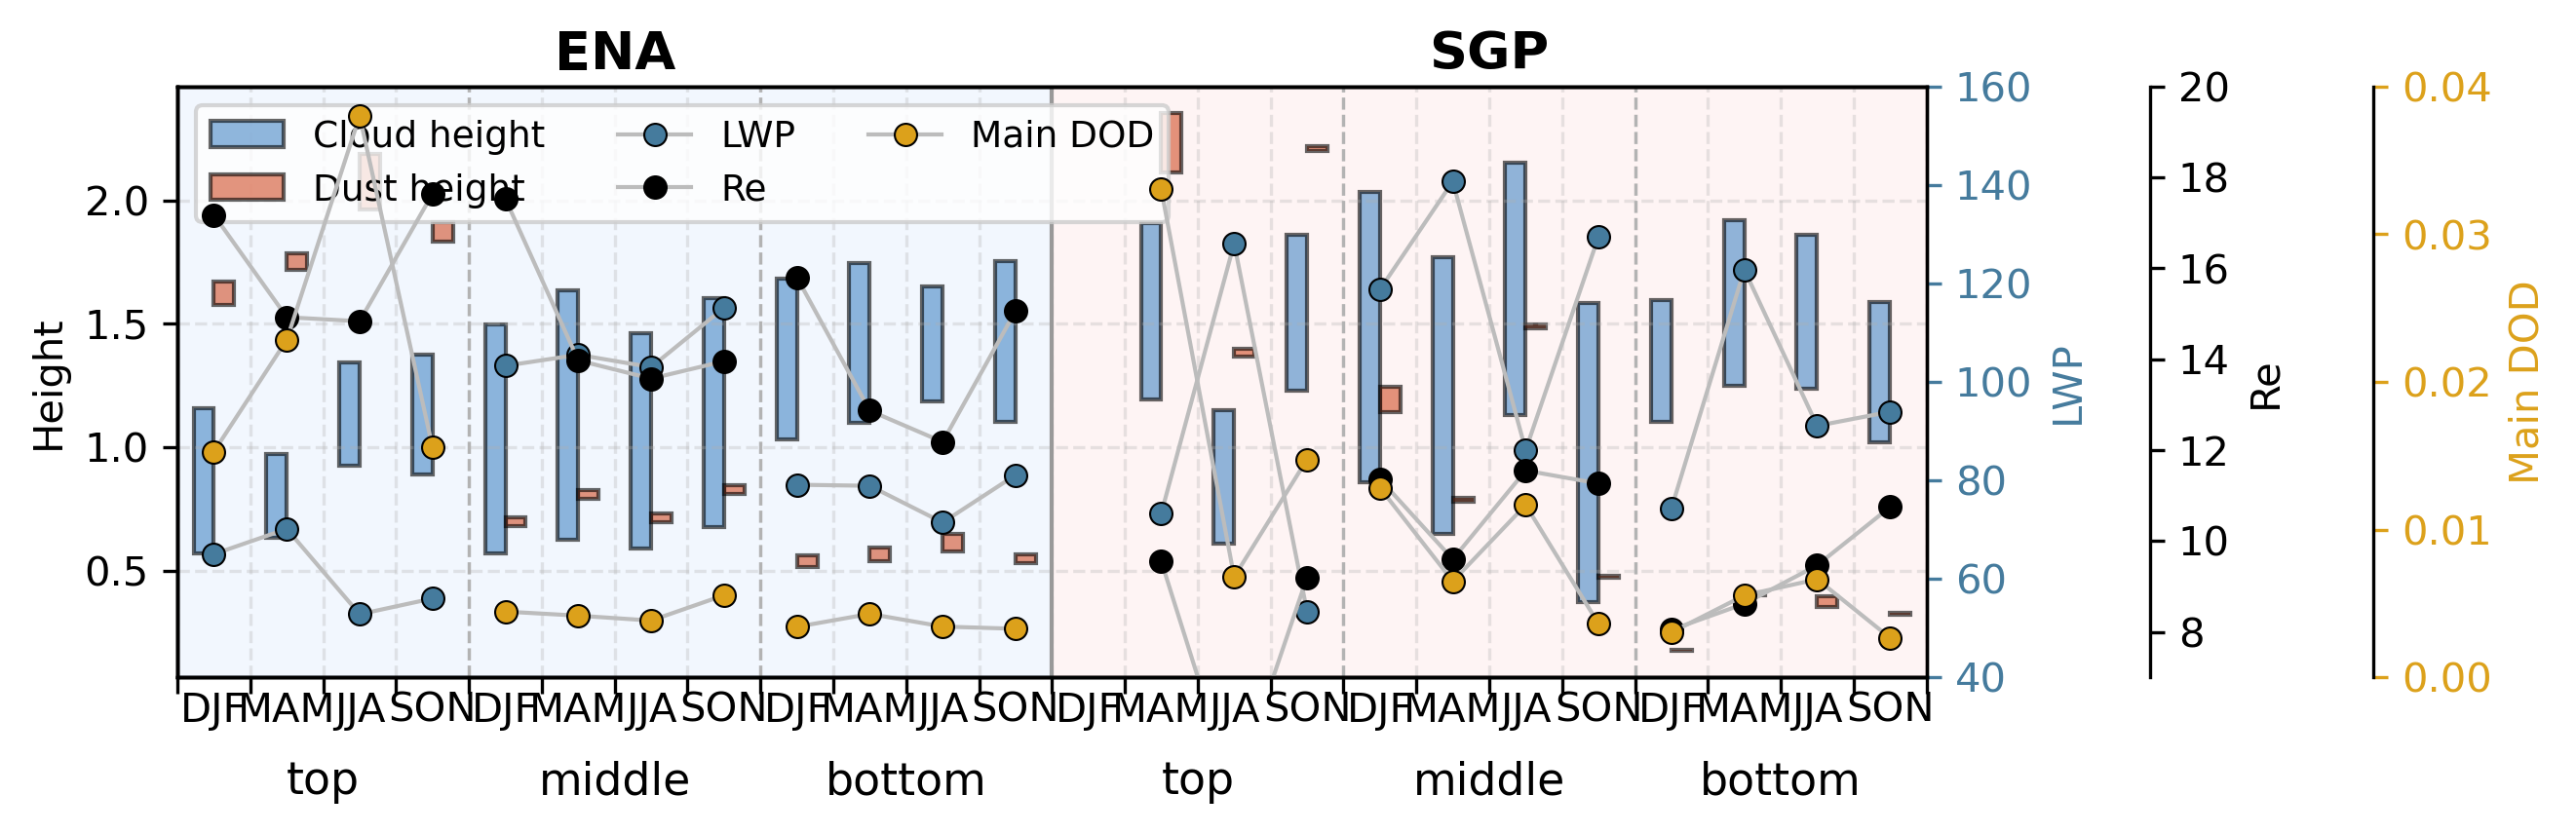

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

cols = ['label','month','cloud_th','dust_th','cloud_bh','dust_bh','lwp','Re','main_dod']
labs = ['top', 'middle', 'bottom']
seas = ['DJF', 'MAM', 'JJA', 'SON']
m2s = {12:'DJF',1:'DJF',2:'DJF', 3:'MAM',4:'MAM',5:'MAM',
       6:'JJA',7:'JJA',8:'JJA', 9:'SON',10:'SON',11:'SON'}

def prep(df):
    df = df[cols].copy()
    df['month'] = pd.to_numeric(df['month'])
    df['season'] = df['month'].map(m2s)
    mi = pd.MultiIndex.from_product([labs, seas], names=['label','season'])
    return (df.groupby(['label','season'], as_index=False).mean(numeric_only=True)
              .set_index(['label','season']).reindex(mi).reset_index())

ena_m = prep(df_ena_abs)
sgp_m = prep(df_sgp_abs)
all_m = pd.concat([ena_m, sgp_m], ignore_index=True)

def lim(s, p=0.05):
    s = np.asarray(s, float)
    vmin, vmax = np.nanmin(s), np.nanmax(s)
    pad = (vmax - vmin) * p if vmax > vmin else 1
    return vmin - pad, vmax + pad

height_ylim = lim(all_m[['cloud_bh','dust_bh','cloud_th','dust_th']].to_numpy().ravel())
lwp_ylim = lim(all_m['lwp'])
re_ylim  = (7, 20)
dod_ylim = lim(all_m['main_dod'])

# Boundary ticks and center positions
x_tick = np.arange(25)           # 0~24
x_mid  = np.arange(24) + 0.5     # 0.5~23.5

x_ena = {'top':x_mid[0:4],  'middle':x_mid[4:8],  'bottom':x_mid[8:12]}
x_sgp = {'top':x_mid[12:16],'middle':x_mid[16:20],'bottom':x_mid[20:24]}
xtlabs = seas * 6

fig, ax = plt.subplots(figsize=(9, 3), dpi=300)
ax_lwp, ax_re, ax_dod = ax.twinx(), ax.twinx(), ax.twinx()
ax_re.spines['right'].set_position(('outward', 55))
ax_dod.spines['right'].set_position(('outward', 110))

for a in [ax_re, ax_dod]:
    a.set_frame_on(True)
    a.patch.set_visible(False)

# Background shading
ax.axvspan(0, 12, color='#dbeafe', alpha=0.35, zorder=0)
ax.axvspan(12, 24, color='#fee2e2', alpha=0.35, zorder=0)
ax.axvline(12, color='0.6', lw=1)

bw = 0.28
line_kw = dict(color='#bcbcbc', lw=1, marker='o', ms=5.5, mec='black', mew=0.5)

def plot_site(dfm, xpos, first=False):
    out = []
    for lab in labs:
        sub = dfm[dfm['label'].eq(lab)].set_index('season').reindex(seas).reset_index()
        xx = xpos[lab]

        b1 = ax.bar(xx - bw/2, sub['cloud_th'] - sub['cloud_bh'], bottom=sub['cloud_bh'],
                    width=bw, color='#4788c6', alpha=0.6, edgecolor='k',
                    label='Cloud height' if first else None)

        b2 = ax.bar(xx + bw/2, sub['dust_th'] - sub['dust_bh'], bottom=sub['dust_bh'],
                    width=bw, color='#d24f29', alpha=0.6, edgecolor='k',
                    label='Dust height' if first else None)

        l1, = ax_lwp.plot(xx, sub['lwp'],      mfc='#457b9d', label='LWP' if first else None, **line_kw)
        l2, = ax_re.plot( xx, sub['Re'],       mfc='black',   label='Re' if first else None, **line_kw)
        l3, = ax_dod.plot(xx, sub['main_dod'], mfc='#dca11b', label='Main DOD' if first else None, **line_kw)

        if first and not out:
            out = [b1, b2, l1, l2, l3]
    return out

h = plot_site(ena_m, x_ena, first=True)
plot_site(sgp_m, x_sgp, first=False)

# Category separator lines
for v in [4, 8, 16, 20]:
    ax.axvline(v, color='0.7', ls='--', lw=0.8)

# Axis limits
ax.set_xlim(0, 24)
ax.set_ylim(height_ylim)
ax_lwp.set_ylim(40, 160)
ax_re.set_ylim(re_ylim)
ax_dod.set_ylim(0, 0.04)

# Major ticks are placed at boundaries without labels
ax.set_xticks(x_tick)
ax.set_xticklabels([''] * len(x_tick))

# Minor ticks are placed at centers with season labels
ax.set_xticks(x_mid, minor=True)
ax.set_xticklabels(xtlabs, minor=True)

ax.tick_params(axis='x', which='major', length=4)
ax.tick_params(axis='x', which='minor', length=0)

ax.set_ylabel('Height')
ax_lwp.set_ylabel('LWP', color='#457b9d')
ax_re.set_ylabel('Re', color='black')
ax_dod.set_ylabel('Main DOD', color='#dca11b')

ax_lwp.tick_params(axis='y', colors='#457b9d')
ax_re.tick_params(axis='y', colors='black')
ax_dod.tick_params(axis='y', colors='#dca11b')

ax.grid(alpha=0.3, ls='--')

# Site titles
ax.text(6, 1.03, 'ENA', transform=ax.get_xaxis_transform(),
        ha='center', fontsize=13, fontweight='bold')
ax.text(18, 1.03, 'SGP', transform=ax.get_xaxis_transform(),
        ha='center', fontsize=13, fontweight='bold')

# Category titles
for xc, lab in zip([2, 6, 10, 14, 18, 22],
                   ['top','middle','bottom','top','middle','bottom']):
    ax.text(xc, -0.14, lab, transform=ax.get_xaxis_transform(),
            ha='center', va='top', fontsize=11)

ax.legend(h, ['Cloud height', 'Dust height', 'LWP', 'Re', 'Main DOD'],
          loc='upper left', fontsize=9, ncol=3)

plt.tight_layout()
plt.savefig("figsave/seasonal_vari.pdf", dpi=300, bbox_inches='tight')
plt.show()

### Fig S2

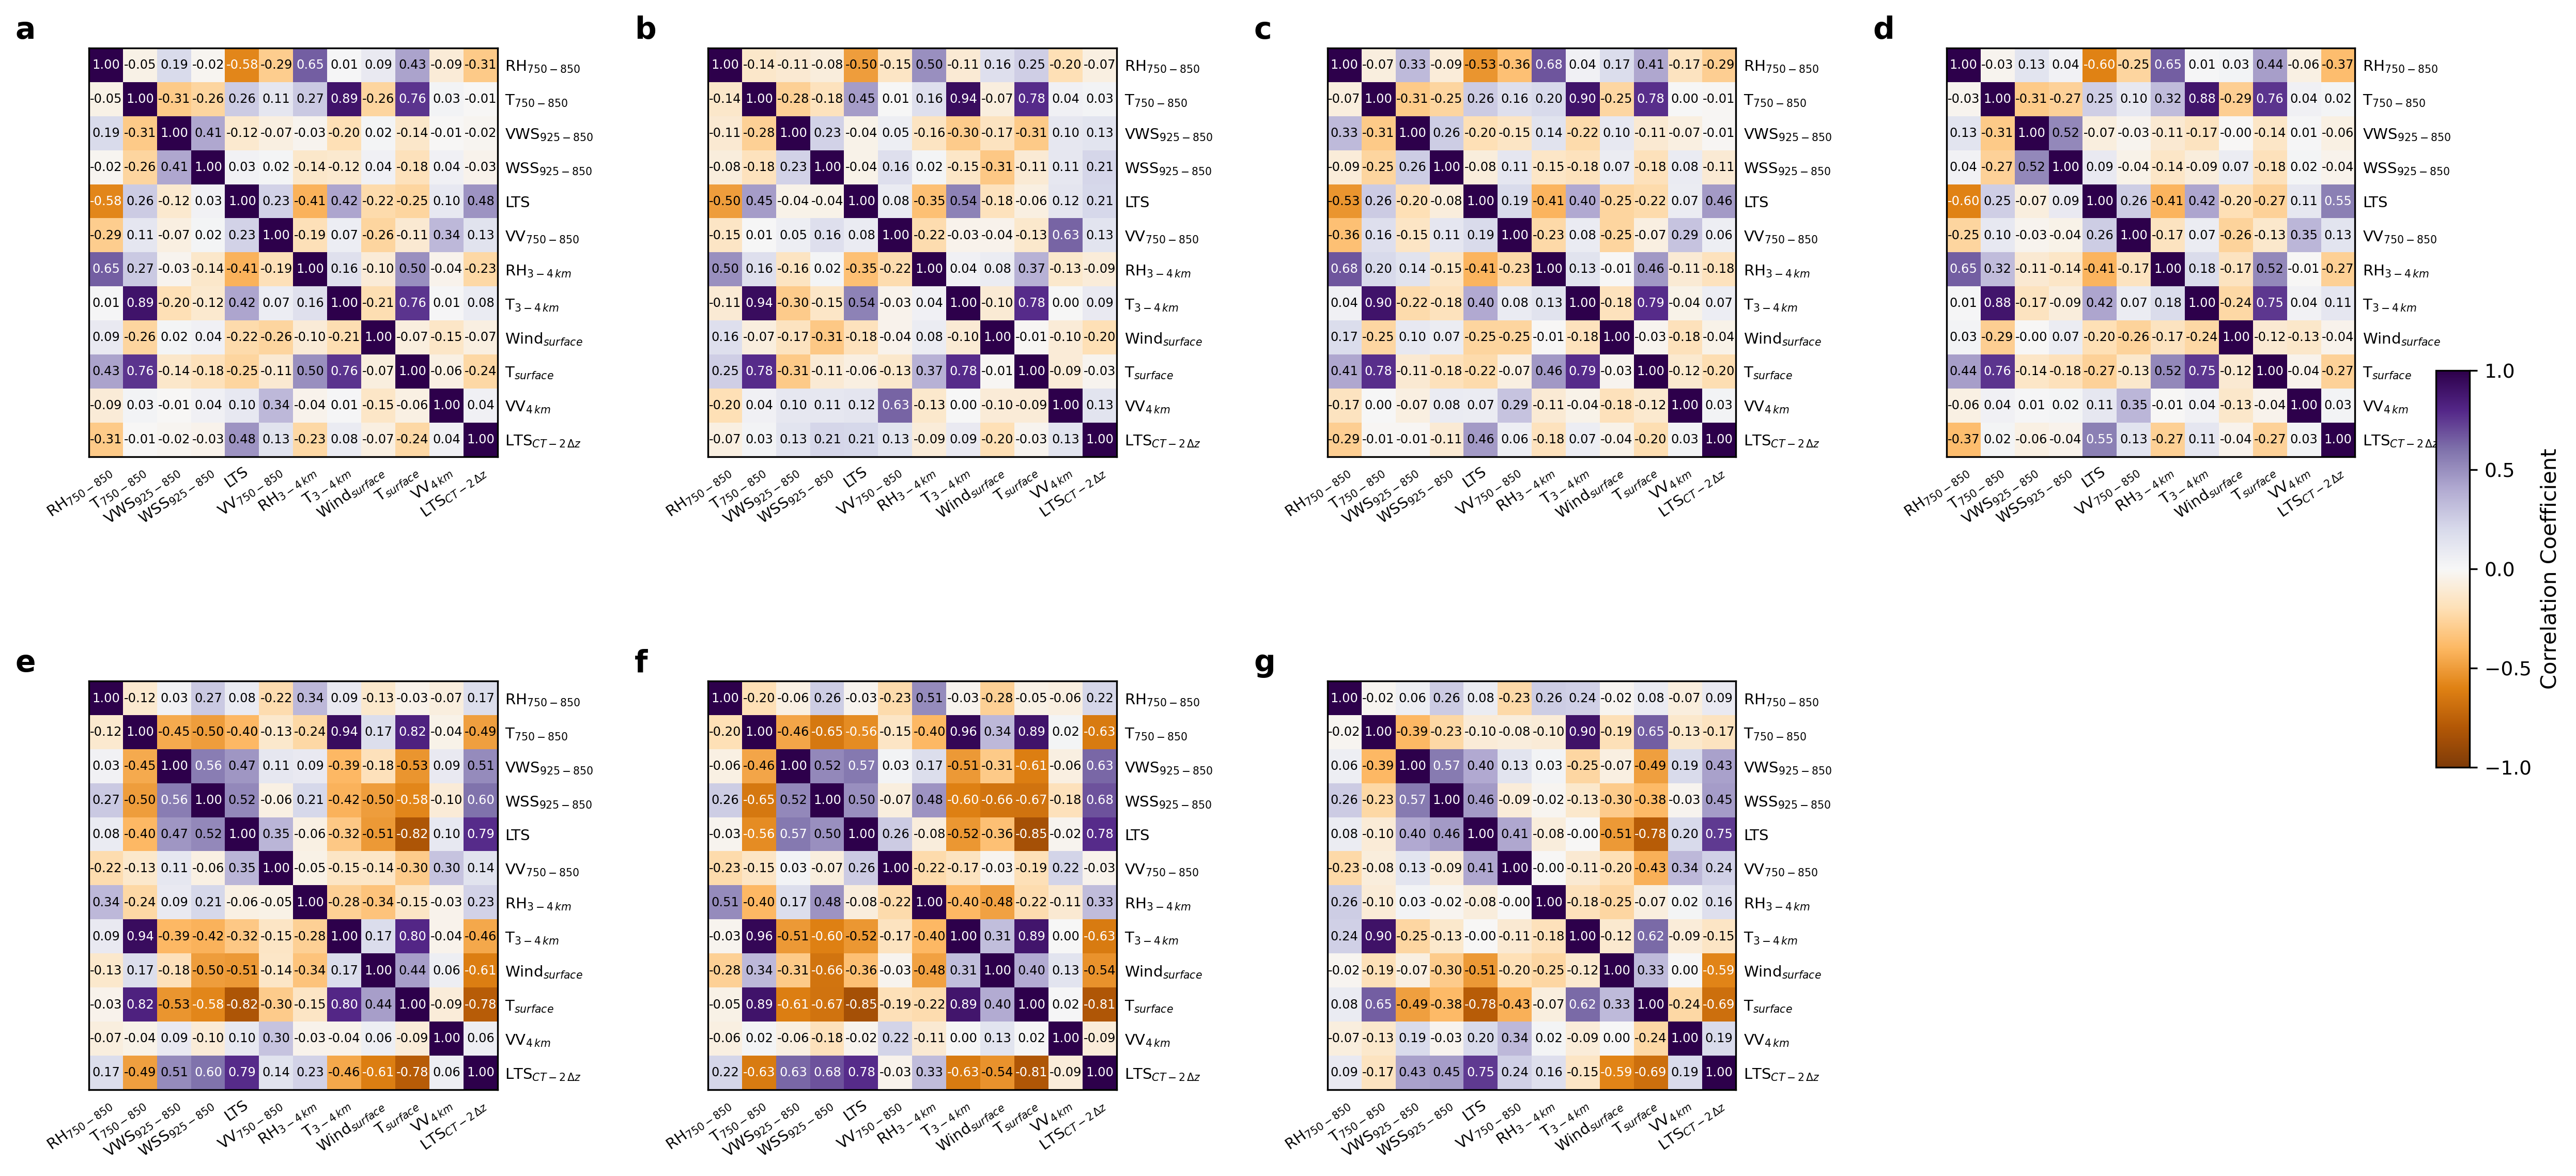

In [15]:
import numpy as np
import matplotlib.pyplot as plt

vars11 = ["RH","TEMP","VWS","WSS","LTS","VV","RH_34","TEMP_34","Wind_surf","TEMP_surf","VV_4","lts_2"]
name_map = {
    "RH":r"RH$_{750-850}$", "TEMP":r"T$_{750-850}$", "VWS":r"VWS$_{925-850}$", "WSS":r"WSS$_{925-850}$",
    "LTS":"LTS", "VV":r"VV$_{750-850}$", "RH_34":r"RH$_{3-4\,km}$",
    "TEMP_34":r"T$_{3-4\,km}$", "Wind_surf":r"Wind$_{surface}$",
    "TEMP_surf":r"T$_{surface}$", "VV_4":r"VV$_{4\,km}$", "lts_2":r"LTS$_{CT-2\,Δz}$"
}
labs, letters = [name_map[v] for v in vars11], list("abcdefg")

groups = [
    df_ena_abs[df_ena_abs["label"].isin(["top","middle","bottom"])],
    df_ena_abs[df_ena_abs["label"].eq("top")],
    df_ena_abs[df_ena_abs["label"].eq("middle")],
    df_ena_abs[df_ena_abs["label"].eq("bottom")],
    df_sgp_abs[df_sgp_abs["label"].isin(["middle","bottom"])],
    df_sgp_abs[df_sgp_abs["label"].eq("middle")],
    df_sgp_abs[df_sgp_abs["label"].eq("bottom")]
]

def draw_corr(ax, df, letter):
    corr = df[vars11].astype(float).corr("pearson")
    im = ax.imshow(corr, vmin=-1, vmax=1, cmap="PuOr")
    n = len(vars11)

    ax.set_xticks(np.arange(n)); ax.set_yticks(np.arange(n))
    ax.set_xticklabels(labs, rotation=35, ha="right", rotation_mode="anchor", fontsize=7)
    ax.set_yticklabels(labs, fontsize=7)
    ax.tick_params(top=False, bottom=True, labeltop=False, labelbottom=True,
                   left=False, right=True, labelleft=False, labelright=True, length=0)

    ax.text(-0.18, 1.08, letter, transform=ax.transAxes, ha="left", va="top",
            fontsize=14, fontweight="bold", clip_on=False)

    for i in range(n):
        for j in range(n):
            v = corr.iloc[i, j]
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=5.8,
                    color="white" if abs(v) >= 0.55 else "black")

    for s in ax.spines.values():
        s.set_linewidth(0.8)

    return im

fig, axes = plt.subplots(2, 4, figsize=(18, 8), dpi=300)
axes = axes.ravel()

for ax, df0, letter in zip(axes[:7], groups, letters):
    im = draw_corr(ax, df0, letter)

axes[7].axis("off")
fig.subplots_adjust(left=0.05, right=0.88, bottom=0.08, top=0.92, wspace=0.35, hspace=0.55)

cax = fig.add_axes([0.90, 0.34, 0.012, 0.32])
cbar = fig.colorbar(im, cax=cax)
cbar.set_label("Correlation Coefficient", fontsize=10)
cbar.set_ticks([-1, -0.5, 0, 0.5, 1])
cbar.ax.tick_params(labelsize=9)

plt.savefig("figsave/corr_meteorological_variables_2x4.pdf", dpi=300, bbox_inches="tight")
plt.show()

## Fig. 2


===== ENA =====
ENA |    top | Cloud median = 0.940 km, n = 236
ENA |    top | Dust  median = 1.766 km, n = 231
ENA | middle | Cloud median = 1.060 km, n = 1216
ENA | middle | Dust  median = 0.761 km, n = 1216
ENA | bottom | Cloud median = 1.390 km, n = 2206
ENA | bottom | Dust  median = 0.596 km, n = 2206
ENA |  total | Cloud median = 1.255 km, n = 3658
ENA |  total | Dust  median = 0.671 km, n = 3653


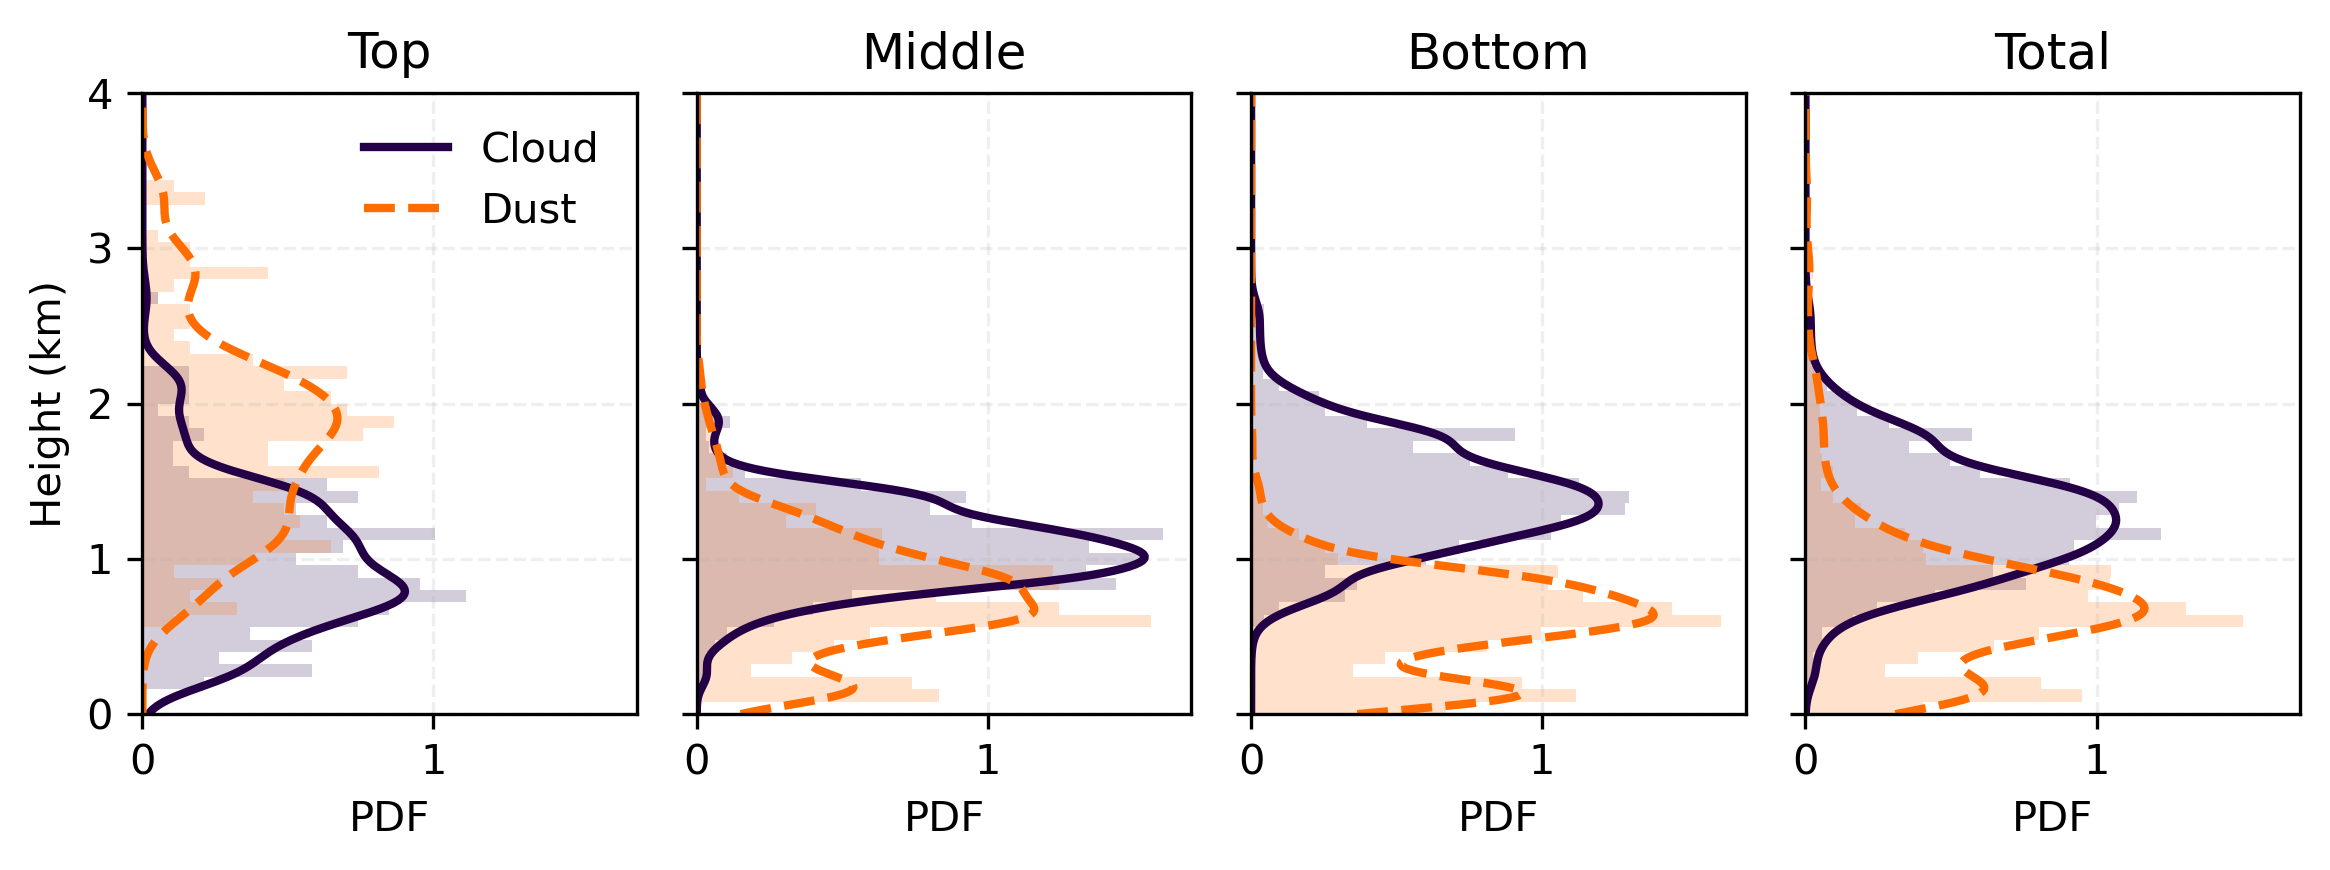


===== SGP =====
SGP |    top | Cloud median = 1.465 km, n = 8
SGP |    top | Dust  median = 2.246 km, n = 8
SGP | middle | Cloud median = 1.165 km, n = 305
SGP | middle | Dust  median = 0.739 km, n = 305
SGP | bottom | Cloud median = 1.390 km, n = 607
SGP | bottom | Dust  median = 0.229 km, n = 607
SGP |  total | Cloud median = 1.345 km, n = 920
SGP |  total | Dust  median = 0.394 km, n = 920


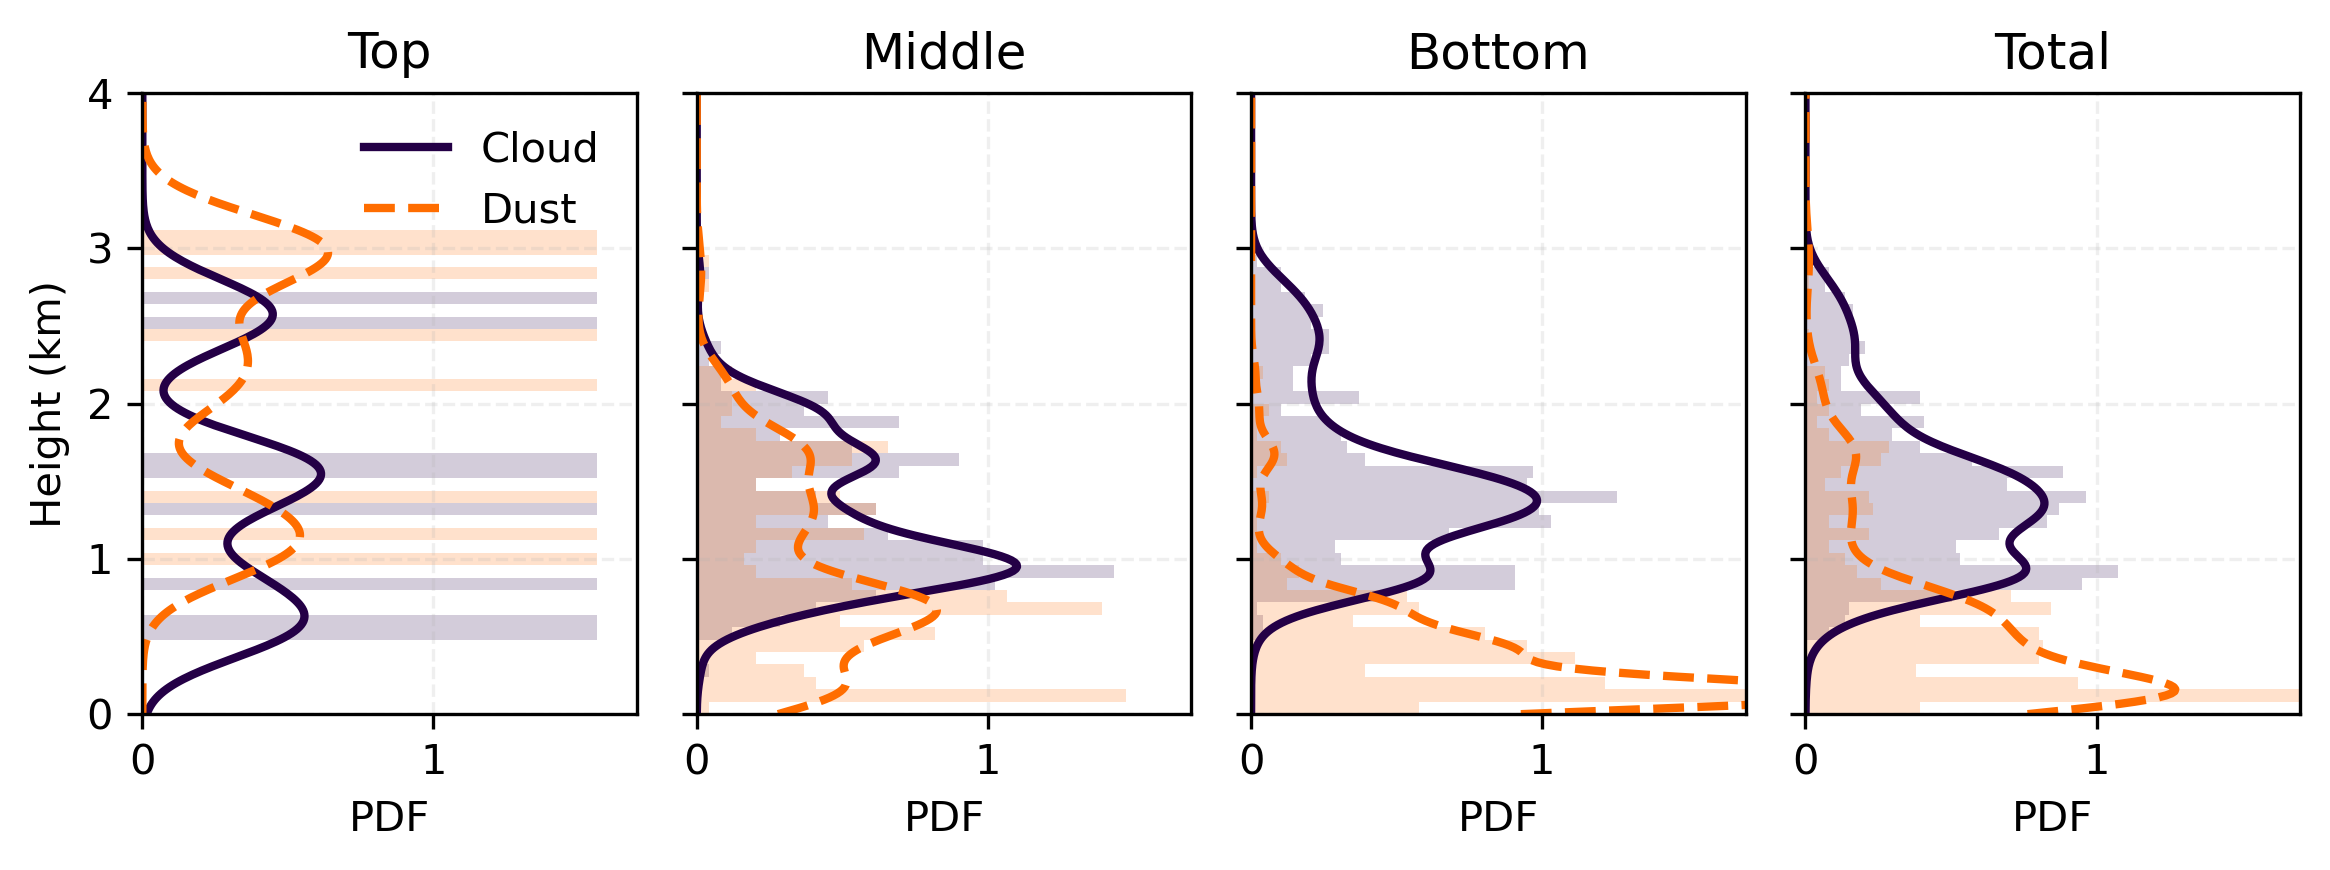

In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

os.makedirs("figsave", exist_ok=True)

cats = ["top", "middle", "bottom"]
panels = cats + ["total"]
sites = {"ENA": df_ena_abs, "SGP": df_sgp_abs}
cols = {"Cloud": "cloud_mh", "Dust": "dust_mh"}
colors = {"Cloud": "#240046", "Dust": "#ff6d00"}
styles = {"Cloud": "-", "Dust": "--"}

xmin, xmax = 0, 4
pdf_min, pdf_max = 0, 1.7
x = np.linspace(xmin, xmax, 300)

for site, df in sites.items():
    fig, axes = plt.subplots(1, 4, figsize=(8, 3), dpi=300, sharey=True)
    print(f"\n===== {site} =====")

    for ax, p in zip(axes, panels):
        d = df[df["label"].isin(cats)] if p == "total" else df[df["label"] == p]

        for name, col in cols.items():
            y = np.asarray(d[col], float)
            y = y[np.isfinite(y) & (y >= xmin) & (y <= xmax)]
            if y.size < 3:
                continue

            ax.hist(y, bins=50, range=(xmin, xmax), density=True,
                    orientation="horizontal", color=colors[name],
                    alpha=0.2, edgecolor="none")

            ax.plot(gaussian_kde(y, bw_method=0.25)(x), x,
                    color=colors[name], lw=2, ls=styles[name], label=name)

            print(f"{site} | {p:>6s} | {name:<5s} median = {np.median(y):.3f} km, n = {y.size}")

        ax.set(title=p.capitalize(), xlim=(pdf_min, pdf_max),
               ylim=(xmin, xmax), xlabel="PDF")
        ax.grid(alpha=0.2, ls="--")

    axes[0].set_ylabel("Height (km)")
    axes[0].legend(frameon=False)

    plt.tight_layout()
    # plt.savefig(f"figsave/{site}_height_total.pdf", dpi=300, bbox_inches="tight")
    plt.show()


===== ENA =====
ENA | DOD | top    median = 0.007, n = 202
ENA | DOD | middle median = 0.003, n = 1209
ENA | DOD | bottom median = 0.002, n = 2203
ENA | COD | top    median = 6.106, n = 236
ENA | COD | middle median = 11.386, n = 1216
ENA | COD | bottom median = 8.608, n = 2206
ENA | LWP | top    median = 48.411, n = 236
ENA | LWP | middle median = 95.842, n = 1216
ENA | LWP | bottom median = 61.257, n = 2206
ENA |  Re | top    median = 14.918, n = 236
ENA |  Re | middle median = 13.093, n = 1216
ENA |  Re | bottom median = 11.926, n = 2206


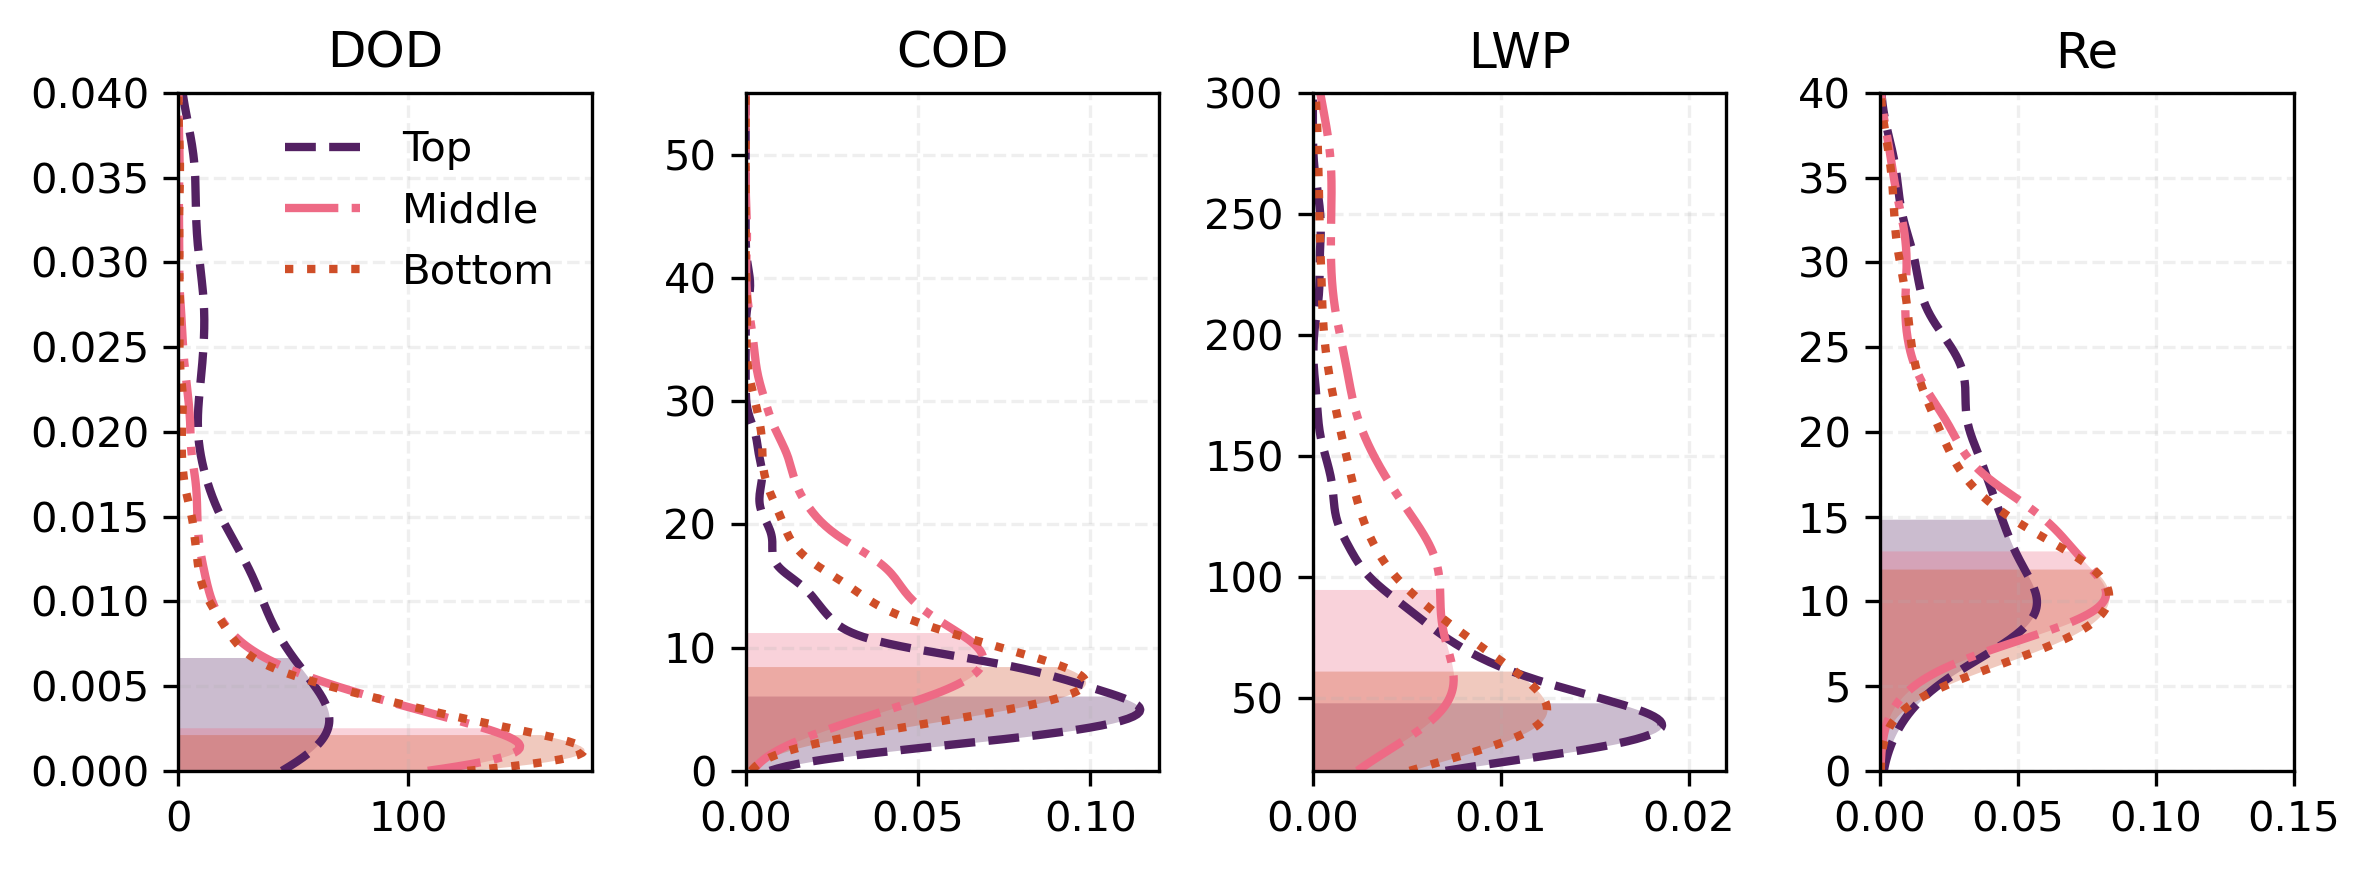


===== SGP =====
SGP | DOD | top    median = 0.007, n = 6
SGP | DOD | middle median = 0.004, n = 298
SGP | DOD | bottom median = 0.003, n = 604
SGP | COD | top    median = 12.551, n = 8
SGP | COD | middle median = 18.281, n = 299
SGP | COD | bottom median = 17.888, n = 594
SGP | LWP | top    median = 66.292, n = 8
SGP | LWP | middle median = 113.263, n = 305
SGP | LWP | bottom median = 88.355, n = 607
SGP |  Re | top    median = 8.379, n = 8
SGP |  Re | middle median = 10.069, n = 305
SGP |  Re | bottom median = 8.241, n = 607


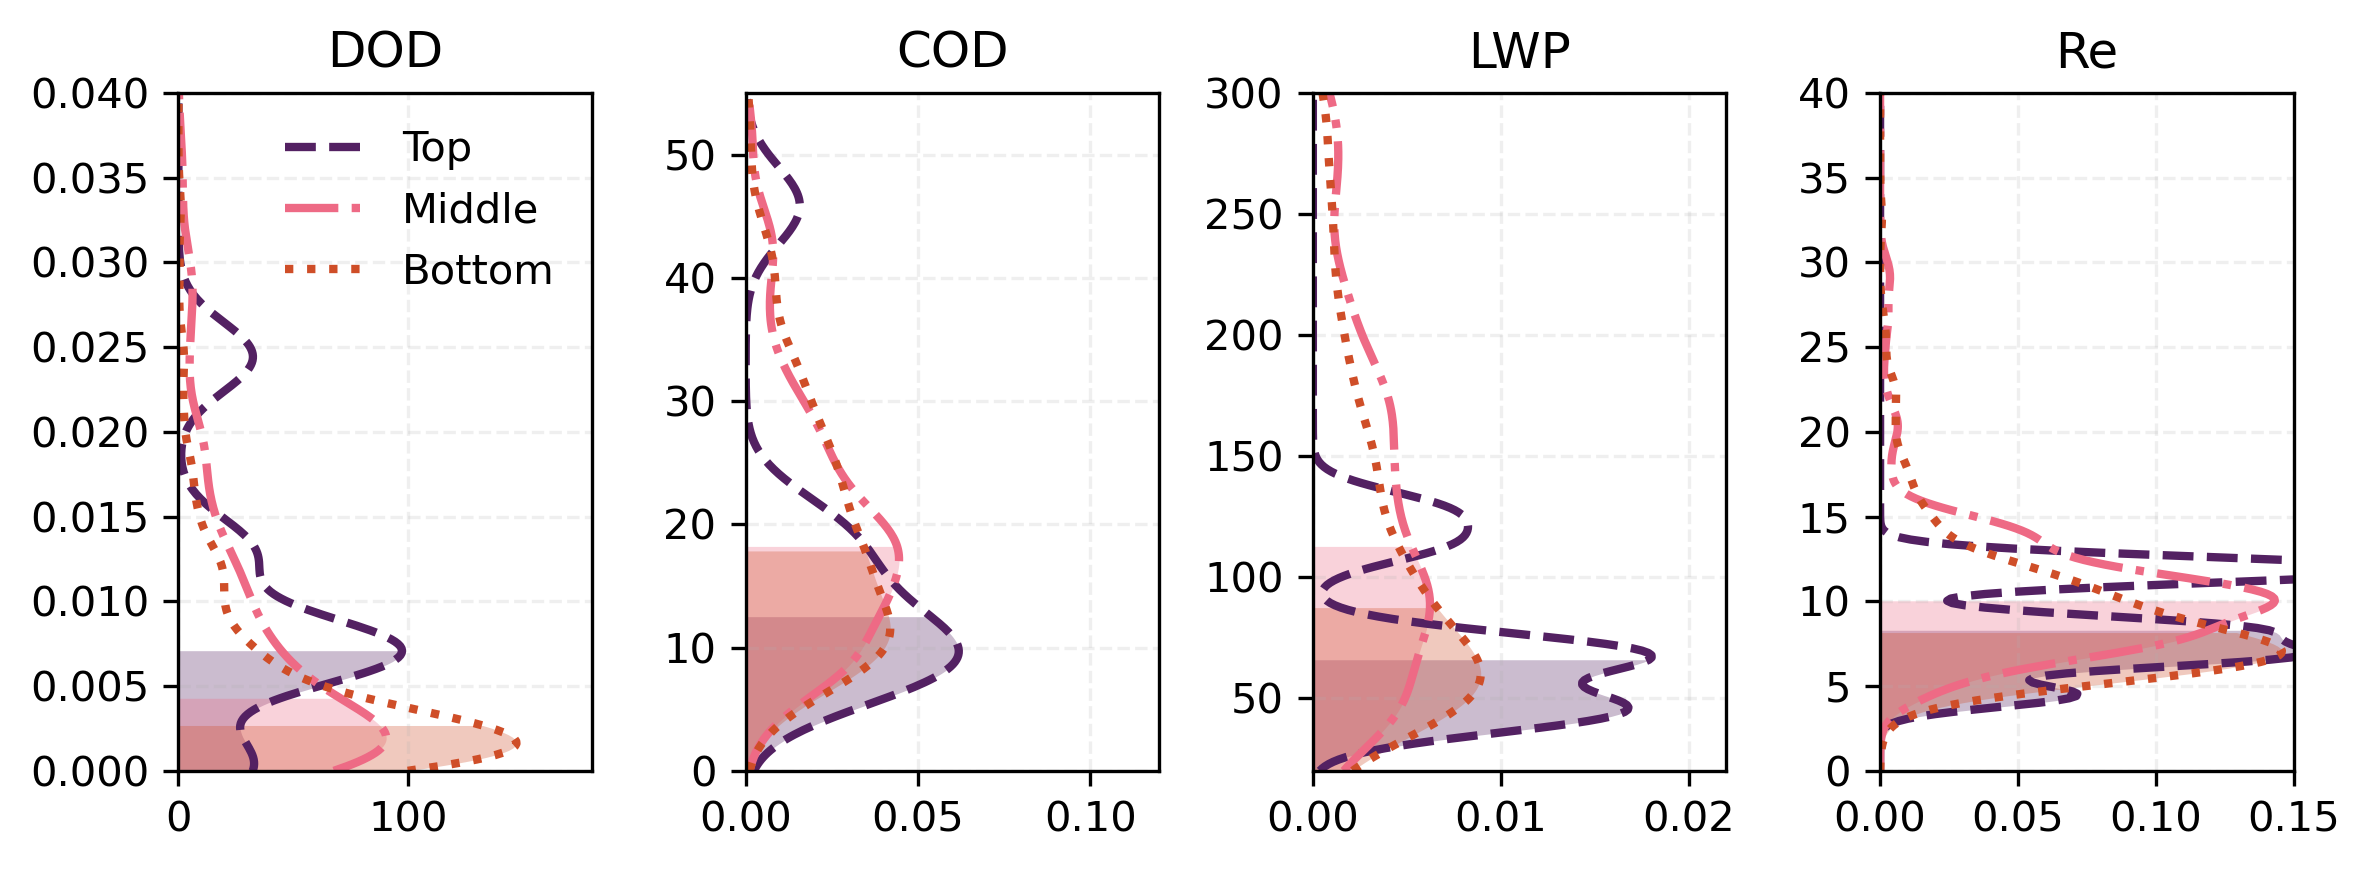

In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

os.makedirs("figsave", exist_ok=True)

cats = ["top", "middle", "bottom"]
vars4 = ["DOD", "COD", "LWP", "Re"]

colmap = {"DOD": "main_dod", "COD": "COD", "LWP": "lwp", "Re": "Re"}
styles = {"top": "--", "middle": "dashdot", "bottom": ":"}
colors = {"top": "#532162", "middle": "#ee6a85", "bottom": "#cf4e28"}

xlims = {"DOD": (0, 0.04), "COD": (0, 55), "LWP": (20, 300), "Re": (0, 40)}
ylims = {"DOD": (0, 180), "COD": (0, 0.12), "LWP": (0, 0.022), "Re": (0, 0.15)}

sites = {"ENA": df_ena_abs, "SGP": df_sgp_abs}

for site, df in sites.items():
    fig, axes = plt.subplots(1, 4, figsize=(8, 3), dpi=300)
    print(f"\n===== {site} =====")

    for ax, var in zip(axes, vars4):
        xmin, xmax = xlims[var]
        ymin, ymax = ylims[var]
        x = np.linspace(xmin, xmax, 300)

        for c in cats:
            y = df.loc[df["label"] == c, colmap[var]].to_numpy(float)
            y = y[np.isfinite(y) & (y > 0) & (xmin <= y) & (y <= xmax)]
            if y.size < 2:
                continue

            kde = gaussian_kde(y, bw_method=0.25)(x)
            med = np.median(y)
            m = x <= med

            ax.plot(kde, x, color=colors[c], lw=2, ls=styles[c], label=c.capitalize())
            ax.fill_betweenx(x[m], kde[m], 0, color=colors[c], alpha=0.3, linewidth=0)

            print(f"{site} | {var:>3s} | {c:<6s} median = {med:.3f}, n = {y.size}")

        ax.set(title=var, xlim=(ymin, ymax), ylim=(xmin, xmax))
        ax.grid(alpha=0.2, ls="--")

    axes[0].legend(frameon=False)
    plt.tight_layout()
    # plt.savefig(f"figsave/{site}PDF_v2.pdf", dpi=300, bbox_inches="tight")
    plt.show()